## Tarea 2 

Nota: Esta tarea fue hecha con el apoyo de la inteligencia artificial. Específicamnete con Gemini

## Parte A: ENO  Enfermedades de Notificación Obligatoria

#### A.0.0 Cargar las librerias a utilizar

In [60]:
#Se comienza cargando las librerias que se utilizaran a lo lagro de toda la tarea
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import os
import zipfile
import textwrap
import re

#### A.0.1 Cargar datos base ENO

In [3]:
#Ahora se cargaran las bases de datos que se utilizaron
#Se seleccionan solo las columnas a utilizar
eno_cols = ["ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
            "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
            "cie_10_diagnostico", "diagnostico", "pais_contagio"]

#Se define la ruta local
ruta_eno = "C:/Users/Mateo/Downloads/iele26_data/eno/20241218_base_eno_final.csv"

#Se carga el archivo CSV con los parámetros solicitados
eno = pd.read_csv(ruta_eno, 
                  sep=";", 
                  encoding="utf-8-sig", 
                  usecols=eno_cols)

#Se reporta shape e info
print("=== Dimensiones del DataFrame (shape) ===")
print(eno.shape)
print("\n=== Información del DataFrame (info) ===")
eno.shape
eno.info()
eno.head()

=== Dimensiones del DataFrame (shape) ===
(333300, 11)

=== Información del DataFrame (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


,region,nacionalidad,cie_10_diagnostico,diagnostico,anho_notificacion,ENO,nombre_instruccion,pais_contagio,sexo,grupo_edad,codigo_comuna_residencia
0,Región de Tarapacá,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,25-29,01107
1,Región de Valparaíso,Desconocido,A90.X,FIEBRE DEL DENGUE,2018,Arbovirus,Desconocido,Desconocido,hombre,70-74,05301
2,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,70-74,05109
3,Región de Valparaíso,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2019,Arbovirus,Desconocido,Desconocido,hombre,40-44,05301
4,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2021,Arbovirus,Desconocido,Desconocido,hombre,60-64,05109


#### A.0.2 Filtrar comunas

In [4]:
#Se coloca el ID de las comunas seleccionadas, las cuales son: San Bernardo y Calera de Tango
MY_COMUNAS = [13401, 13403] 

#Se Filtra la base de datos para quedarse solo con las comunas seleccionadas
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)]
print(f"Filas en mis comunas (eno_com): {len(eno_com):,}")

#Contar cuantas filas estan anonimizadas
anonimizadas = eno[eno["codigo_comuna_residencia"] == "*****"]
cantidad_anonimizadas = len(anonimizadas)
porcentaje_anonimizadas = (cantidad_anonimizadas / len(eno)) * 100

print(f"\nFilas anonimizadas ('*****') en el dataset completo: {cantidad_anonimizadas:,}")
print(f"Porcentaje de datos anonimizados: {porcentaje_anonimizadas:.2f}%")

Filas en mis comunas (eno_com): 2,256

Filas anonimizadas ('*****') en el dataset completo: 148,217
Porcentaje de datos anonimizados: 44.47%


#### A.0.3 Limpieza a la variable nacionalidad

In [5]:
#Se reporta la distribución inicial de las 2 comunas en conjunto
print("=== Distribución inicial de Nacionalidad (San Bernardo y Calera de Tango) ===")
print(eno_com["nacionalidad"].value_counts(dropna=False))

#Se cuenta cuántas filas corresponden a "Desconocido"
filas_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
porcentaje_desc = (filas_desconocido / len(eno_com)) * 100

print("\n=== Descarte de filas ===")
print(f"Se descartarán {filas_desconocido:,} filas con nacionalidad 'Desconocido'.")
print(f"Esto representa el {porcentaje_desc:.2f}% de los datos en San Bernardo y Calera de Tango.")

#Se filtra y se crea un nuevo dataframe para los análisis por nacionalidad
eno_com_clean = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print("\n=== Datos limpios ===")
print(f"Filas restantes para análisis específicos por nacionalidad: {len(eno_com_clean):,}")

=== Distribución inicial de Nacionalidad (San Bernardo y Calera de Tango) ===
nacionalidad
Chile          1191
Desconocido     905
Extranjero      160
Name: count, dtype: int64

=== Descarte de filas ===
Se descartarán 905 filas con nacionalidad 'Desconocido'.
Esto representa el 40.12% de los datos en San Bernardo y Calera de Tango.

=== Datos limpios ===
Filas restantes para análisis específicos por nacionalidad: 1,351


#### A.0.4 Reporte del lapso de tiempo

In [6]:
#Se obtiene el rango de los años
anio_min = eno_com["anho_notificacion"].min()
anio_max = eno_com["anho_notificacion"].max()

print(f"=== Lapso de tiempo ===")
print(f"El rango de notificaciones en San Bernardo y Calera de Tango abarca desde {anio_min} hasta {anio_max}.\n")

#Se cuenta las notificaciones por año y se ordena por el año
notificaciones_por_anio = eno_com["anho_notificacion"].value_counts().sort_index()

# Se convierte en un dateframe para presentarlo como una "tabla simple"
tabla_anios = pd.DataFrame({
    "Año de Notificación": notificaciones_por_anio.index,
    "Total Notificaciones": notificaciones_por_anio.values
})

print("=== Notificaciones por año en San Bernardo y Calera de Tango ===")
display(tabla_anios)

=== Lapso de tiempo ===
El rango de notificaciones en San Bernardo y Calera de Tango abarca desde 2007 hasta 2024.

=== Notificaciones por año en San Bernardo y Calera de Tango ===


,Año de Notificación,Total Notificaciones
0,2007,97
1,2008,87
2,2009,85
3,2010,79
4,2011,96
5,2012,94
6,2013,81
7,2014,98
8,2015,125
9,2016,104


## Parte A.1 Tendencias de Notificación a lo Largo del Tiempo
#### Parte A.1.1 Tendencia general

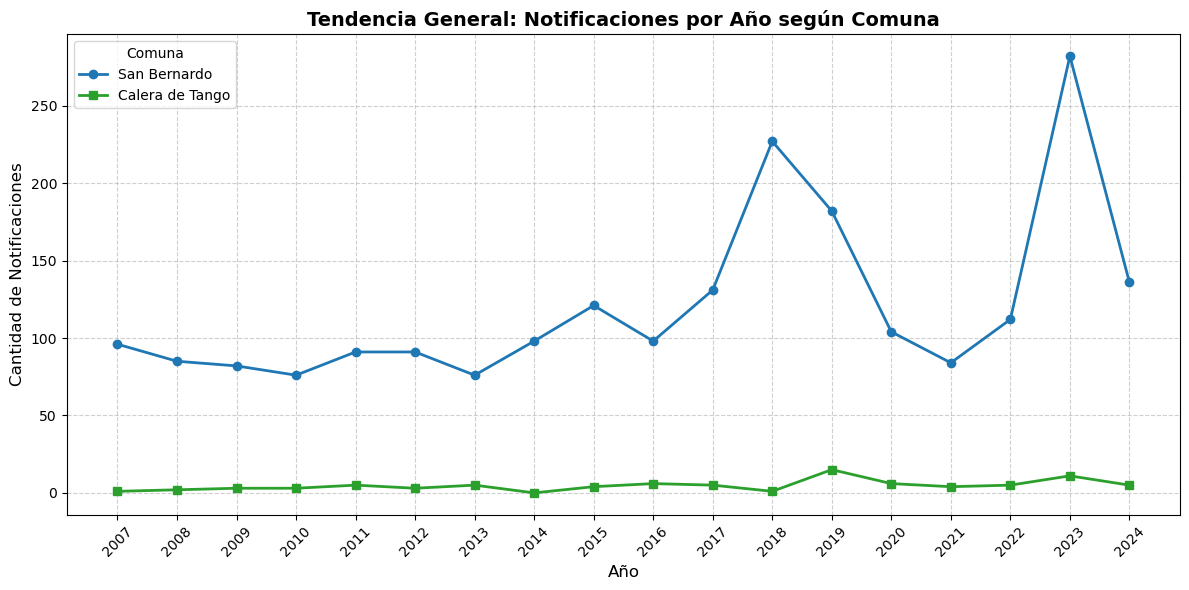

In [7]:
#Se agrupa los datos cruzando el Año y el Código de Comuna
tendencia_comunas = pd.crosstab(eno_com['anho_notificacion'], eno_com['codigo_comuna_residencia'])

#Se renombran las columnas para que la leyenda muestre los nombres reales y no los números
tendencia_comunas.rename(columns={'13401': 'San Bernardo', '13403': 'Calera de Tango'}, inplace=True)

#Se configura y crea el gráfico
plt.figure(figsize=(12, 6))

# Se grafica San Bernardo solo si hay datos
if 'San Bernardo' in tendencia_comunas.columns:
    plt.plot(tendencia_comunas.index, tendencia_comunas['San Bernardo'], 
             marker='o', linestyle='-', color='tab:blue', linewidth=2, label='San Bernardo')

#Se grafica Calera de Tango solo si hay datos
if 'Calera de Tango' in tendencia_comunas.columns:
    plt.plot(tendencia_comunas.index, tendencia_comunas['Calera de Tango'], 
             marker='s', linestyle='-', color='tab:green', linewidth=2, label='Calera de Tango')

#Se colocan los títulos
plt.title('Tendencia General: Notificaciones por Año según Comuna', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Notificaciones', fontsize=12)
plt.xticks(tendencia_comunas.index, rotation=45)
plt.legend(title="Comuna")
plt.grid(True, linestyle='--', alpha=0.6)

# Se muestra el gráfico
plt.tight_layout()
plt.show()

Lo destacable del gráfico acá viene a ser la comuna de San Bernado por la cantidad de habitantes que posee vs Calera de Tango. Desde el año 2007 hasta el 2016 se ven pequeñas variaciones pero nada que se alejara demasiado del promedio. La cosa cambia a partir del año 2018 donde se genera un alza del doble sobre los años anteriores. Posterior a ese año, baja y vuelve un poco más abajo del promedio en años de pandemia y vuelve a tener su úlitmo peak en el año 2023 superando los 250 casos y decayendo al año soguiente.

La posible explicación del alza del 2018 puede deberse a que el 2018 el gobierno lanzó una campaña para concientizar a las personas sobre las enfermedades de transmisión sexual como el VIH, lo que provocó que las personas fueran a chequearse. Posterior a ese año, el estallido social y la pandemia generó que este típo de enfermedades obligatorias de reportar pasara a segundo plano. Ya cuando el país logró estabilizarse, lo más probable es que en esos años que no se generó conciencia de ese tipo de enfermedades provocó la propagación.

#### Parte A.1.2 Tendencia por nacionalidad

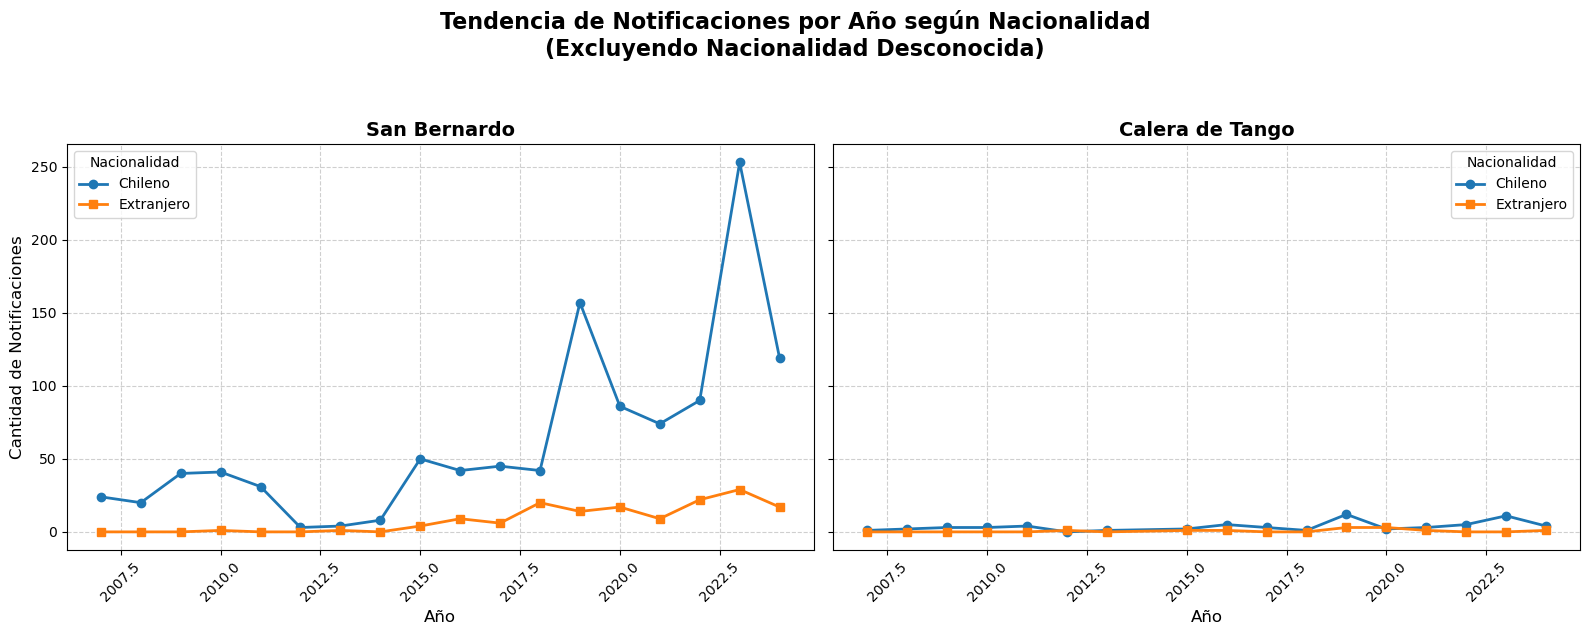

In [29]:
#Diccionario para mapear los nombres
nombres_comunas = {'13401': 'San Bernardo', '13403': 'Calera de Tango'}
codigos = ['13401', '13403']

#Se crea una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

#Se Itera sobre cada comuna para crear su propio gráfico
for i, (cod, ax) in enumerate(zip(codigos, axes)):
    
    # Se filtra los datos limpios solo para esta comuna
    df_com = eno_com_clean[eno_com_clean['codigo_comuna_residencia'] == cod]
    
    #Se descartan los "Desconocido"
    df_com = df_com[df_com['nacionalidad'] != 'Desconocido']
    
    if df_com.empty:
        ax.set_title(f'{nombres_comunas[cod]} (Sin datos)')
        continue

    #Se agrupa por año y nacionalidad para esta comuna específica
    tendencia_nac = pd.crosstab(df_com["anho_notificacion"], df_com["nacionalidad"])

    # Graficar Chilenos
    if "Chile" in tendencia_nac.columns:
        ax.plot(tendencia_nac.index, tendencia_nac["Chile"], 
                marker='o', linestyle='-', color='tab:blue', linewidth=2, label="Chileno")
    
    # Graficar Extranjeros
    if "Extranjero" in tendencia_nac.columns:
        ax.plot(tendencia_nac.index, tendencia_nac["Extranjero"], 
                marker='s', linestyle='-', color='tab:orange', linewidth=2, label="Extranjero")

    # Se personaliza cada sub-gráfico
    ax.set_title(f'{nombres_comunas[cod]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title="Nacionalidad")
    
    #Etiqueta del eje Y solo en el primer gráfico
    if i == 0:
        ax.set_ylabel('Cantidad de Notificaciones', fontsize=12)

#Título
plt.suptitle('Tendencia de Notificaciones por Año según Nacionalidad\n(Excluyendo Nacionalidad Desconocida)', fontsize=16, fontweight='bold', y=1.05)

# Se muestra el gráfico
plt.tight_layout()
plt.show()

Al igual que el gráfico anterior, lo destacable es la comuna de San Bernardo.

Acá se puede visualizar que la población chilena es la que más casos de enfermedades obligatorias de reportar posee el sistema de salud de dicha comuna. Las causas, pueden ser varias como la poca educación sexual que hay en general en el país.

## Parte A.2 Perfiles de Enfermedades
#### Parte A.2.1 Principales enfermedades

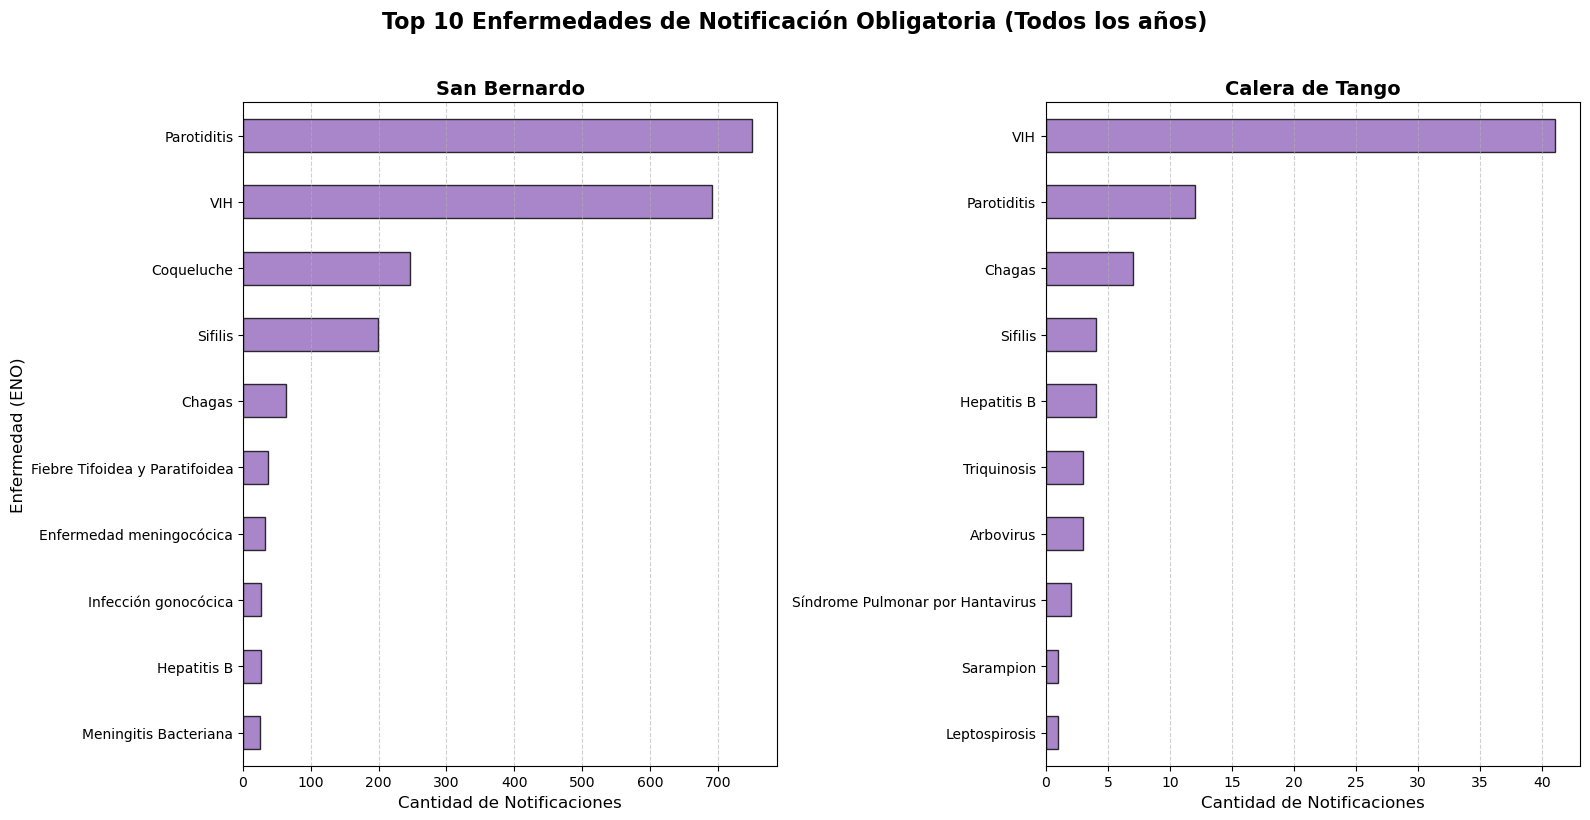

In [24]:
#Se define los códigos y nombres de las comunas
comunas_info = {'13401': 'San Bernardo', '13403': 'Calera de Tango'}
codigos = ['13401', '13403']

# 2. Se crea una figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#Se iterar sobre cada comuna para crear su propio gráfico Top 10
for cod, ax in zip(codigos, axes):
    nombre_comuna = comunas_info[cod]
    
    # Se filtra los datos solo para esta comuna
    df_com = eno_com[eno_com['codigo_comuna_residencia'] == cod]
    
    # Se calcula el Top 10 específico de esta comuna
    top_10 = df_com["ENO"].value_counts().head(10)
    
    # Se crea el gráfico de barras horizontales
    top_10.sort_values(ascending=True).plot(
        kind='barh', 
        ax=ax,
        color='tab:purple', 
        edgecolor='black',
        alpha=0.8
    )
    
    # Se personaliza títulos y etiquetas para cada sub-gráfico
    ax.set_title(f'{nombre_comuna}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Notificaciones', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    # se pone la etiqueta "Enfermedad" solo en el primer gráfico para no ser redundante
    if cod == '13401':
        ax.set_ylabel('Enfermedad (ENO)', fontsize=12)
    else:
        ax.set_ylabel('')

#Título general para toda la figura
plt.suptitle('Top 10 Enfermedades de Notificación Obligatoria (Todos los años)', fontsize=16, fontweight='bold', y=1.02)

#Mostrar gráficos
plt.tight_layout()
plt.show()

En Calera de Tango y en San Bernardo comparten (en distintas posiciones) el top 1 y 2, lo que habla que son las enfermedades más comunas y a las cuales el gobierno debería echarle un ojo

#### Parte A.2.2 Perfiles de enfermedades por nacionalidad

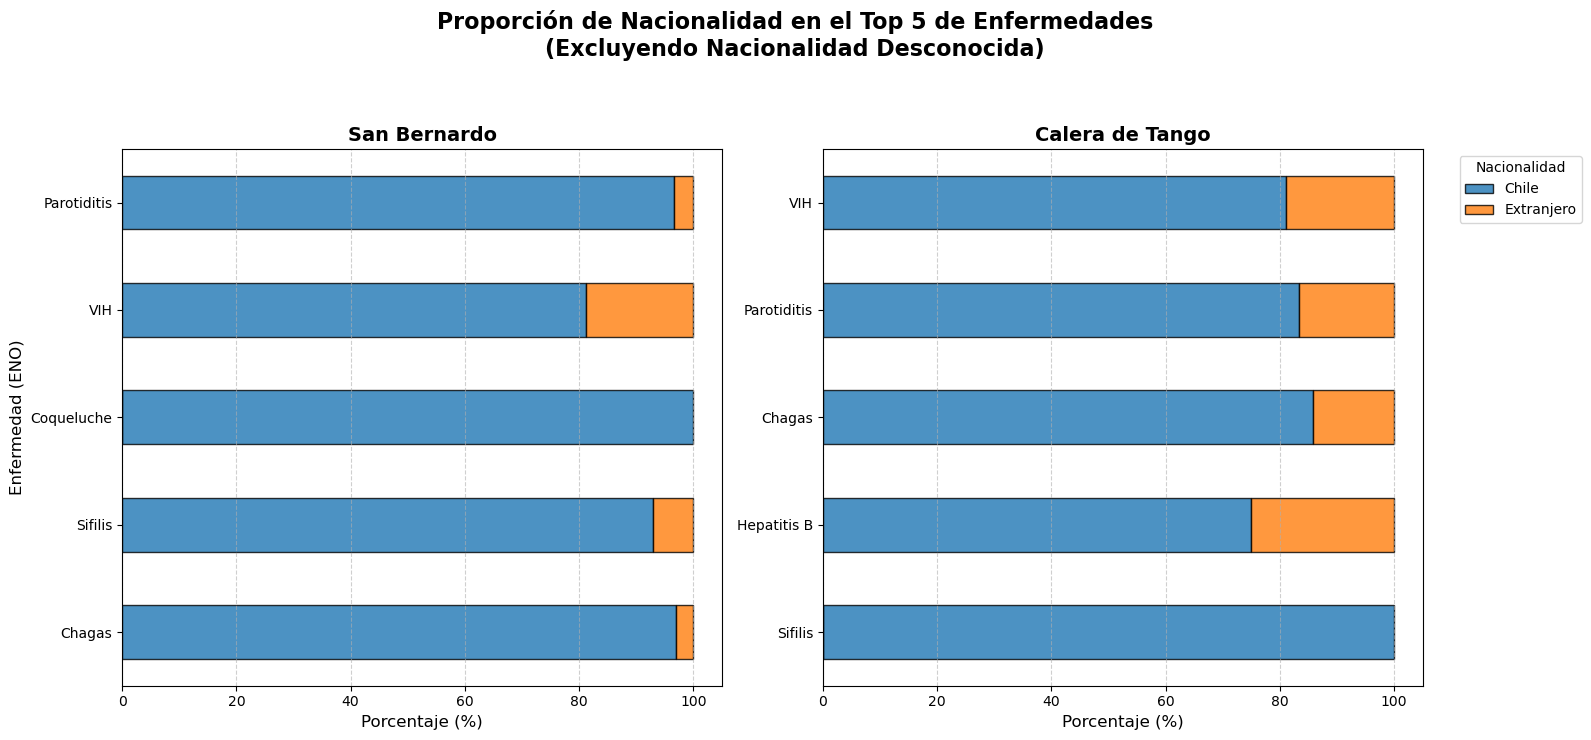


=== Tabla de Proporciones (%) - San Bernardo ===


nacionalidad,Chile,Extranjero
ENO,,
Parotiditis,96.64,3.36
VIH,81.25,18.75
Coqueluche,100.00,0.00
Sifilis,92.96,7.04
Chagas,96.88,3.12



=== Tabla de Proporciones (%) - Calera de Tango ===


nacionalidad,Chile,Extranjero
ENO,,
VIH,81.08,18.92
Parotiditis,83.33,16.67
Chagas,85.71,14.29
Hepatitis B,75.00,25.00
Sifilis,100.00,0.00


In [9]:
#Se definen los códigos y nombres de tus comunas
comunas_info = {'13401': 'San Bernardo', '13403': 'Calera de Tango'}
codigos = ['13401', '13403']

#Diccionario para guardar las tablas y mostrarlas al final de forma ordenada
tablas_proporciones = {}

#Se crea una figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#Se itera sobre cada comuna para crear su propio gráfico y calcular su tabla
for i, (cod, ax) in enumerate(zip(codigos, axes)):
    nombre_comuna = comunas_info[cod]
    
    #Top 5 REAL usando TODOS los datos
    df_com_total = eno_com[eno_com['codigo_comuna_residencia'] == cod]
    if df_com_total.empty:
        ax.set_title(f'{nombre_comuna} (Sin datos)')
        continue
    top_5_reales = df_com_total["ENO"].value_counts().head(5).index
    
    #Ahora se preparan los datos para las proporciones
    df_com = eno_com_clean[eno_com_clean['codigo_comuna_residencia'] == cod]
    df_com = df_com[df_com['nacionalidad'] != 'Desconocido']
    df_top5 = df_com[df_com["ENO"].isin(top_5_reales)]
    
    #Si por casualidad una enfermedad se queda sin datos al sacar los desconocidos, se saltará
    if df_top5.empty:
        ax.set_title(f'{nombre_comuna} (Sin datos de nacionalidad para el Top 5)')
        continue
    
    #Se calculará la proporción cruzando ENO y nacionalidad
    proporciones_nac = pd.crosstab(df_top5["ENO"], df_top5["nacionalidad"], normalize='index') * 100
    
    #Se asegurará el orden del top 5 real
    top_5_presentes = [enf for enf in top_5_reales if enf in proporciones_nac.index]
    proporciones_nac = proporciones_nac.loc[top_5_presentes]
    
    #Se guardará la tabla redondeada a 2 decimales para mostrarla después
    tablas_proporciones[nombre_comuna] = proporciones_nac.round(2)
    
    #Se creará el gráfico de barras apiladas en el sub-gráfico correspondiente
    proporciones_nac.plot(
        kind='barh', 
        stacked=True, 
        ax=ax,
        color=['tab:blue', 'tab:orange'], 
        edgecolor='black',
        alpha=0.8
    )
    
    #Se Invierte el eje Y para que la enfermedad más frecuente aparezca arriba
    ax.invert_yaxis()
    
    #Se personaliza cada sub-gráfico
    ax.set_title(f'{nombre_comuna}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    #Se Pone la etiqueta "Enfermedad" solo en el primer gráfico
    if i == 0:
        ax.set_ylabel('Enfermedad (ENO)', fontsize=12)
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        ax.set_ylabel('')
        ax.legend(title='Nacionalidad', bbox_to_anchor=(1.05, 1), loc='upper left')

# Título general para toda la figura
plt.suptitle('Proporción de Nacionalidad en el Top 5 de Enfermedades\n(Excluyendo Nacionalidad Desconocida)', fontsize=16, fontweight='bold', y=1.05)

#Se Ajusta márgenes y mostrar gráficos
plt.tight_layout()
plt.show()

#Se  muestra las tablas de proporciones que guardamos
for nombre_comuna, tabla in tablas_proporciones.items():
    print(f"\n=== Tabla de Proporciones (%) - {nombre_comuna} ===")
    display(tabla)

Acá pasa que en ambas comunas los extranjeros no ocupan ni el 30% en alguna de estas enfermedades, lo que puede deberse a que al ser extranjeros, su registro de enfermedades sea más complicado que un habitante nacional o tal vez por miedo a ser deportados o por que no quieren ir a los centros médicos. En fin, muchas variables que pueden ser las que afecten a este resultadp

#### Parte A.2.3 Distribución por grupo de edad para la principal enfermedad

La enfermedad con más registros de nacionalidad conocida es: VIH


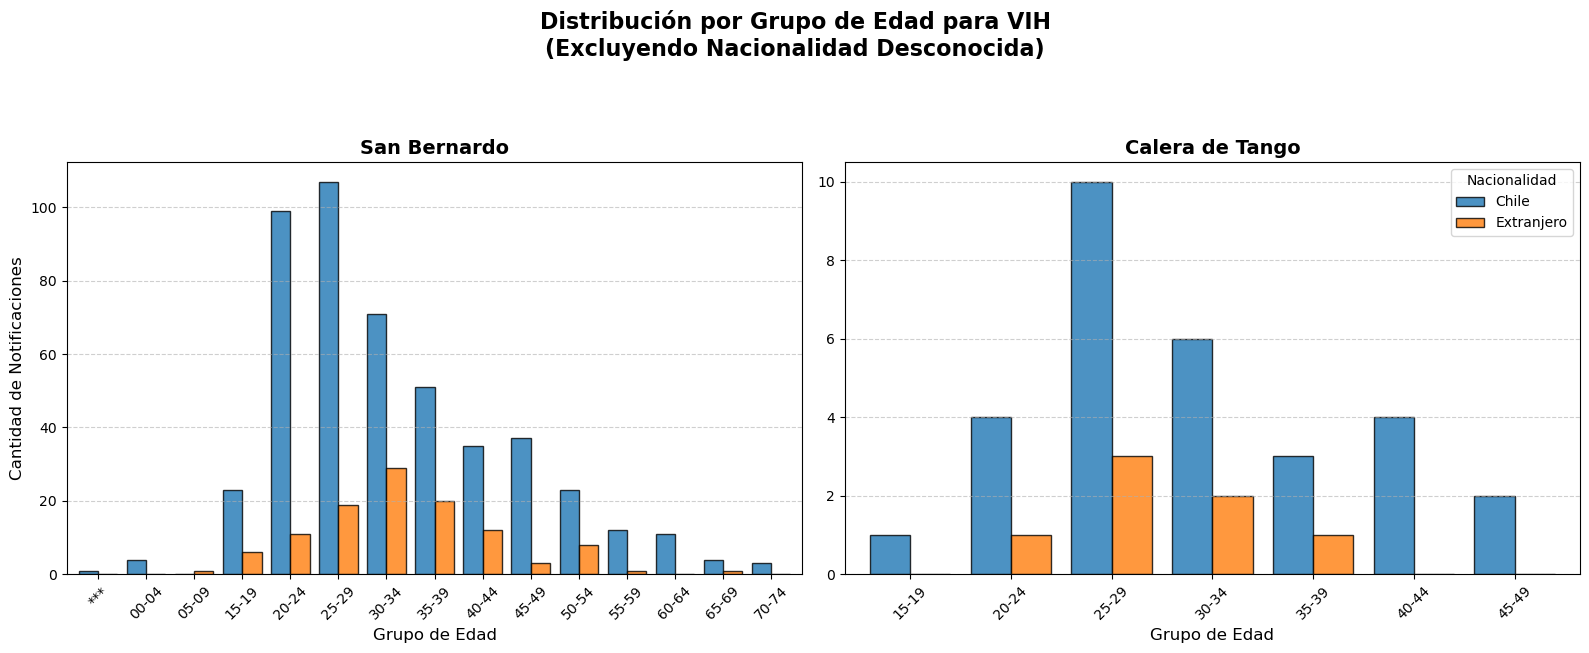

In [32]:
#Se identifica la enfermedad más común
top_enfermedad = eno_com_clean["ENO"].value_counts().index[0]
print(f"La enfermedad con más registros de nacionalidad conocida es: {top_enfermedad}")

#Se filtra para esa enfermedad específica dentro de los datos limpios
df_top_enf = eno_com_clean[eno_com_clean["ENO"] == top_enfermedad]

#Se define comunas para los gráficos
comunas_info = {'13401': 'San Bernardo', '13403': 'Calera de Tango'}
codigos = ['13401', '13403']

#Se crea figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (cod, ax) in enumerate(zip(codigos, axes)):
    nombre_comuna = comunas_info[cod]
    
    # Filtrar para la comuna específica
    df_com = df_top_enf[df_top_enf['codigo_comuna_residencia'] == cod]
    
    if df_com.empty:
        ax.set_title(f'{nombre_comuna}\n(Sin casos registrados de {top_enfermedad})', fontsize=14)
        continue
        
    # Agrupar por grupo de edad y nacionalidad (solo Chile y Extranjero)
    dist_edad = pd.crosstab(df_com["grupo_edad"], df_com["nacionalidad"]).sort_index()
    
    # Crear el gráfico de barras agrupadas
    dist_edad.plot(
        kind='bar', 
        ax=ax, 
        width=0.8, 
        color=['tab:blue', 'tab:orange'], 
        edgecolor='black', 
        alpha=0.8
    )
    
    # Personalizar sub-gráfico
    ax.set_title(f'{nombre_comuna}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Grupo de Edad', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Configurar etiquetas y leyenda
    if i == 0:
        ax.set_ylabel('Cantidad de Notificaciones', fontsize=12)
        if ax.get_legend():
            ax.get_legend().remove()
    else:
        ax.set_ylabel('')
        if ax.get_legend():
            ax.legend(title='Nacionalidad')

#Título principal indicando la exclusión
plt.suptitle(f'Distribución por Grupo de Edad para {top_enfermedad}\n(Excluyendo Nacionalidad Desconocida)', fontsize=16, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

El analisis parte con que la engermedad que afecta más a los habitantes nacionales y extranjeros es el VIH y no la parotiditis. Esto ocurre porque los de la úlitma enfermedad al momento de anotar su nacionalidad no ocurre de manera correcta y lo rellenan con el valor de "Desconocida", por lo que se llegan a perder interpretaciones valiosas. 

En ambas comunas se logra apreciar que para los chilenos, la edad más afectada es el rango de 25 a 29 años, seguido del rango de 20 a 24 años. No es sopresa este rango por la misma fisiología del ser humano, donde la edad provoca tener varias relaciones sexuales con varias personas y esto, junto con una pobre educación sexual, provoca este tipo de resultados.

Con respecto a los extranjeros, el rango de 25 a 29 y 30 a 34 son los más afectados. Puede deberse a que la mayoria de la población extranjera en Chile es de este mismo rango etario (además de las razones argumentadas para la población chilena)

## Parte 3 Vista Espacial
#### A.3.1 Recuento de notificaciones y Tasa por comuna

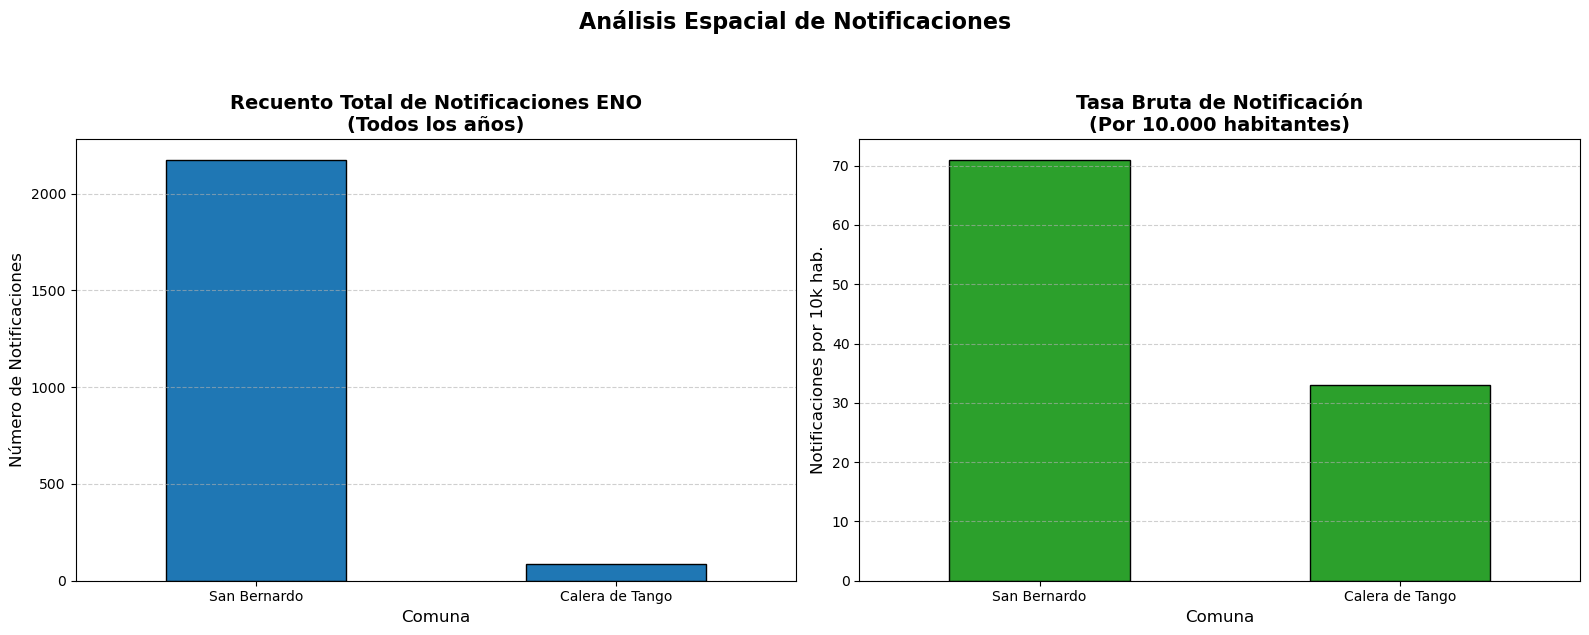


=== Tabla Resumen de Notificaciones y Tasas ===


,nombre_comuna,total_notificaciones,pop_total,tasa_10k
0,San Bernardo,2172,306371,70.89
1,Calera de Tango,84,25491,32.95


In [11]:
#Se cargan el resumen de la Tarea 1
path_summary = "C:/Users/Mateo/Downloads/tarea1_comuna_summary.csv"
df_poblacion = pd.read_csv(path_summary)

#Se prepara el recuento de notificaciones
recuento_eno = eno_com['codigo_comuna_residencia'].value_counts().reset_index()
recuento_eno.columns = ['codigo_comuna', 'total_notificaciones']
recuento_eno['codigo_comuna'] = recuento_eno['codigo_comuna'].astype(int)

#Se realiza la unión con los datos de población
df_analisis_espacial = pd.merge(recuento_eno, df_poblacion, on='codigo_comuna', how='inner')

#Se calcula la Tasa Bruta de Notificación
df_analisis_espacial['tasa_10k'] = (df_analisis_espacial['total_notificaciones'] / df_analisis_espacial['pop_total']) * 10000

#Se visualizan los 2 gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Gráfico 1: Recuento Total
df_analisis_espacial.plot(kind='bar', x='nombre_comuna', y='total_notificaciones', 
                          ax=ax1, color='tab:blue', edgecolor='black', legend=False)
ax1.set_title('Recuento Total de Notificaciones ENO\n(Todos los años)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Notificaciones', fontsize=12)
ax1.set_xlabel('Comuna', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

#Gráfico 2: Tasa por 10.000 habitantes
df_analisis_espacial.plot(kind='bar', x='nombre_comuna', y='tasa_10k', 
                          ax=ax2, color='tab:green', edgecolor='black', legend=False)
ax2.set_title('Tasa Bruta de Notificación\n(Por 10.000 habitantes)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Notificaciones por 10k hab.', fontsize=12)
ax2.set_xlabel('Comuna', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Título general
plt.suptitle('Análisis Espacial de Notificaciones', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Se mustra la tabla resumen
print("\n=== Tabla Resumen de Notificaciones y Tasas ===")
display(df_analisis_espacial[['nombre_comuna', 'total_notificaciones', 'pop_total', 'tasa_10k']].round(2))

Esto habla bien de cada comuna, pese a tener varios casos, comuníca que solo se presenta un 0,7% aproximadamente de notificaciones por cada 10000 habitantes, lo cual es bajo.

## Parte 4 Tabla Resumen de ENO a Nivel de Comuna

In [59]:
# ==========================================
# B.4 Tabla Resumen de GRD a Nivel de Comuna
# ==========================================

import pandas as pd
import re

# Se carga la base de población de la Tarea 1 para obtener pop_total y los códigos de comuna
ruta_poblacion = "C:/Users/Mateo/Downloads/tarea1_comuna_summary.csv"
df_pob = pd.read_csv(ruta_poblacion)

# Se estandariza el nombre de la comuna para facilitar el cruce de datos
df_pob["nombre_comuna_upper"] = df_pob["nombre_comuna"].str.upper()

# Se define la función que procesa y calcula todas las métricas requeridas por comuna
def build_grd_summary(df):
    total = len(df)
    chilean = (df["nat_group"] == "Chilean").sum()
    foreign = (df["nat_group"] == "Foreign").sum()
    
    pct_foreign = (foreign / total) * 100 if total > 0 else 0
    
    mean_los = df["los"].mean()
    mean_los_chi = df[df["nat_group"] == "Chilean"]["los"].mean()
    mean_los_for = df[df["nat_group"] == "Foreign"]["los"].mean()
    
    # Se utiliza la columna de severidad numérica procesada en pasos anteriores
    mean_sev = df["IR_29301_SEVERIDAD"].mean()
    
    # Se calcula la tasa de mortalidad basándose en la columna identificadora creada en B.2.3
    mort_rate = (df["fallecido"].sum() / total) * 100 if total > 0 else 0

    # Se extraen los 3 principales capítulos CIE-10, limpiando prefijos y códigos
    top3_series = df["Capítulo"].value_counts().head(3).index.to_series()
    top3_clean = (
        top3_series.str.replace(r'^Cap\.\d+\s*', '', regex=True)
        .str.replace(r'\s*\([A-Z0-9\-]+\)$', '', regex=True)
        .str.strip()
    )
    top3_str = ", ".join(top3_clean.tolist())

    return pd.Series({
        "grd_total": total,
        "grd_chilean": chilean,
        "grd_foreign": foreign,
        "grd_pct_foreign": round(pct_foreign, 2),
        "grd_mean_los": round(mean_los, 2),
        "grd_mean_los_chilean": round(mean_los_chi, 2),
        "grd_mean_los_foreign": round(mean_los_for, 2),
        "grd_mean_severity": round(mean_sev, 2),
        "grd_mortality_rate": round(mort_rate, 2),
        "grd_top3_chapters": top3_str
    })

# Se genera el resumen aplicando la función a la base agrupada por comuna
grd_summary = grd_com.groupby("COMUNA").apply(build_grd_summary).reset_index()

# Se une el resumen con los datos de la Tarea 1 para integrar códigos y población total
grd_summary = grd_summary.merge(
    df_pob[["codigo_comuna", "nombre_comuna", "nombre_comuna_upper", "pop_total"]],
    left_on="COMUNA",
    right_on="nombre_comuna_upper",
    how="left"
)

# Se calcula la tasa bruta de hospitalización por cada 10.000 habitantes
grd_summary["grd_rate_per_10k"] = round((grd_summary["grd_total"] / grd_summary["pop_total"]) * 10000, 2)

# Se seleccionan y ordenan las columnas según las especificaciones de la pauta
columnas_finales = [
    "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean",
    "grd_foreign", "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
    "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
    "grd_top3_chapters", "grd_rate_per_10k"
]
grd_summary = grd_summary[columnas_finales]

# Se muestra la tabla resultante en el notebook
print("=== Resumen Final GRD por Comuna ===")
display(grd_summary)

# Se exporta la tabla a un archivo CSV guardado directamente en la carpeta de Descargas
ruta_descargas = "C:/Users/Mateo/Downloads/tarea2_grd_summary.csv"
grd_summary.to_csv(ruta_descargas, index=False, encoding="utf-8-sig")

print(f"\nArchivo guardado exitosamente en: {ruta_descargas}")

=== Resumen Final GRD por Comuna ===


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13403,Calera de Tango,1539,1502,37,2.40,7.22,7.24,6.43,1.75,2.60,"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS ...",603.74
1,13401,San Bernardo,44506,42580,1926,4.33,6.01,6.04,5.52,1.47,2.35,"EMBARAZO, PARTO Y PUERPERIO, ENFERMEDADES DEL ...",1452.68



Archivo guardado exitosamente en: C:/Users/Mateo/Downloads/tarea2_grd_summary.csv


Acá basicamente se ve el resumen de todo lo hablado anteriormente en forma de resumen.

## Parte B: GRD  Altas Hospitalarias 
#### B.0 Carga y Limpieza de Datos

In [25]:
# Se seleccionan solo las columnas a utilizar
grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

# Se define la ruta local de la carpeta
ruta_grd = "C:/Users/Mateo/Downloads/iele26_data/grd"

# Se define el diccionario con los nombres del ZIP, el TXT interno y el encoding real
archivos_grd = {
    2022: {"zip": "GRD_PUBLICO_2022.zip", "txt": "GRD_PUBLICO_EXTERNO_2022.txt", "encoding": "utf-16"},
    2023: {"zip": "GRD_PUBLICO_2023.zip", "txt": "GRD_PUBLICO_2023.txt", "encoding": "utf-16"},
    2024: {"zip": "GRD_PUBLICO_2024.zip", "txt": "GRD_PUBLICO_2024.txt", "encoding": "latin-1"}
}

# Se crea una lista vacía para almacenar los DataFrames de cada año
frames = []

# Se iteran los años utilizando el diccionario
for year, info in archivos_grd.items():
    # Se construye la ruta completa hacia el archivo .zip
    zippath = os.path.join(ruta_grd, info["zip"])
    
    # Se extrae y carga el archivo directamente desde el ZIP con su encoding específico
    with zipfile.ZipFile(zippath) as z:
        with z.open(info["txt"]) as f:
            df_year = pd.read_csv(
                f, 
                sep="|", 
                usecols=grd_cols,
                encoding=info["encoding"], 
                low_memory=False
            )
            
    # Se agrega una columna para identificar el año de los datos
    df_year["year"] = year
    
    # Se añade el DataFrame a la lista
    frames.append(df_year)

# Se concatenan todos los años en un único DataFrame
grd = pd.concat(frames, ignore_index=True)

# Se reporta shape e info
print("=== Dimensiones del DataFrame (shape) ===")
print(grd.shape)
print(f"\nTotal de egresos registrados (3 años): {len(grd):,}")

print("\n=== Información del DataFrame (info) ===")
grd.info()

grd.head()

=== Dimensiones del DataFrame (shape) ===
(3058240, 15)

Total de egresos registrados (3 años): 3,058,240

=== Información del DataFrame (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3058240 entries, 0 to 3058239
Data columns (total 15 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   SEXO                 object
 1   FECHA_NACIMIENTO     object
 2   COMUNA               object
 3   NACIONALIDAD         object
 4   TIPO_INGRESO         object
 5   ESPECIALIDAD_MEDICA  object
 6   FECHA_INGRESO        object
 7   FECHAALTA            object
 8   TIPOALTA             object
 9   DIAGNOSTICO1         object
 10  DIAGNOSTICO2         object
 11  IR_29301_COD_GRD     object
 12  IR_29301_SEVERIDAD   object
 13  IR_29301_MORTALIDAD  object
 14  year                 int64 
dtypes: int64(1), object(14)
memory usage: 350.0+ MB


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


#### Parte B.0.2 Filtrar  comunas

In [26]:
# Se definen los nombres de las comunas seleccionadas en mayúsculas (formato GRD)
my_comuna_names = ["SAN BERNARDO", "CALERA DE TANGO"]

# Se filtra la base de datos GRD para conservar solo las comunas asignadas
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)]

# Se reporta el total de altas filtradas en el conjunto de datos
print(f"Egresos en mis comunas (grd_com): {len(grd_com):,}")

# Se calcula y reporta el número de altas por año en las comunas seleccionadas
altas_por_ano = grd_com["year"].value_counts().sort_index()

print("\n=== Número de altas por año en las comunas seleccionadas ===")
print(altas_por_ano.to_string())

Egresos en mis comunas (grd_com): 46,045

=== Número de altas por año en las comunas seleccionadas ===
year
2022    15127
2023    15222
2024    15696


#### B.0.3 Calcular la duración de la estadía

In [29]:
# Se crea una copia explícita del DataFrame para evitar advertencias de Pandas
grd_com = grd_com.copy()

# Se transforman las columnas de fecha a formato datetime
# Se utilizan format='mixed' y errors='coerce' para lidiar con formatos combinados o corruptos
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], format='mixed', dayfirst=True, errors='coerce')
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], format='mixed', dayfirst=True, errors='coerce')

# Se calcula la duración de la estadía ("los") en días
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# Se calculan las estadísticas descriptivas solicitadas para la distribución
# Pandas automáticamente ignora los valores nulos (NaN) al calcular esto
media_los = grd_com["los"].mean()
mediana_los = grd_com["los"].median()
min_los = grd_com["los"].min()
max_los = grd_com["los"].max()

# Se reporta la distribución inicial
print("=== Distribución de la duración de estadía (los) ===")
print(f"Media:   {media_los:.2f} días")
print(f"Mediana: {mediana_los:.0f} días")
print(f"Mínimo:  {min_los:.0f} días")
print(f"Máximo:  {max_los:.0f} días")

# Se contabilizan los registros con errores temporales explícitos (los < 0)
errores_datos = len(grd_com[grd_com["los"] < 0])

# Se filtra la base de datos para excluir dichos errores
# Al mantener solo los >= 0, también se eliminan automáticamente los valores nulos por fechas inválidas
grd_com = grd_com[grd_com["los"] >= 0]

# Se reporta la limpieza realizada
print(f"\nSe eliminaron {errores_datos} filas explícitas debido a errores de datos (los < 0).")
print(f"Total de egresos restantes tras la limpieza: {len(grd_com):,}")

=== Distribución de la duración de estadía (los) ===
Media:   6.05 días
Mediana: 2 días
Mínimo:  0 días
Máximo:  508 días

Se eliminaron 0 filas explícitas debido a errores de datos (los < 0).
Total de egresos restantes tras la limpieza: 46,045


#### B.0.4 Crear una agrupación por nacionalidad

In [30]:
# Se genera una nueva columna 'nat_group' clasificando las nacionalidades de forma binaria
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)

# Se calcula la cantidad total de egresos por cada grupo de nacionalidad
distribucion_nacionalidad = grd_com["nat_group"].value_counts()

# Se calcula el porcentaje que representa cada grupo sobre el total
porcentajes_nacionalidad = grd_com["nat_group"].value_counts(normalize=True) * 100

# Se reporta la distribución de la agrupación por nacionalidad
print("=== Distribución por Nacionalidad (nat_group) ===")
print("Cantidad de egresos por grupo:")
print(distribucion_nacionalidad.to_string())

print("\nPorcentaje por grupo:")
print(porcentajes_nacionalidad.apply(lambda x: f"{x:.2f}%").to_string())

=== Distribución por Nacionalidad (nat_group) ===
Cantidad de egresos por grupo:
nat_group
Chilean    44082
Foreign     1963

Porcentaje por grupo:
nat_group
Chilean    95.74%
Foreign     4.26%


#### B.0.5 Unir diagnósticos con CIE-10

In [32]:
# Se define la ruta local del archivo Excel con los códigos CIE-10
ruta_cie10 = "C:/Users/Mateo/Downloads/iele26_data/grd/CIE-10.xlsx"

# Se carga la hoja "CIE 10" del archivo Excel
cie10 = pd.read_excel(ruta_cie10, sheet_name="CIE 10")

# Se realiza la unión (merge) de la base de egresos con la tabla CIE-10
# Se utilizan los nombres exactos de las columnas del Excel (con tilde)
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1", right_on="Código", how="left"
)

# Se contabilizan las filas que no lograron unirse correctamente (donde la columna 'Capítulo' quedó nula)
fallos_union = grd_com["Capítulo"].isnull().sum()

# Se reporta el resultado de la unión solicitada
print("=== Resultado de la unión con CIE-10 ===")
print(f"Filas que fallaron en unirse (Capítulo nulo): {fallos_union:,}")
print(f"Total de egresos con diagnóstico asignado correctamente: {len(grd_com) - fallos_union:,}")

=== Resultado de la unión con CIE-10 ===
Filas que fallaron en unirse (Capítulo nulo): 1
Total de egresos con diagnóstico asignado correctamente: 46,044


## B.1 Perfil Diagnóstico
Por tema de visualización, se decidió que se hará un gráfico para cada comuna, cosa que no se sature información
#### B.1.1 Principales capítulos de diagnóstico

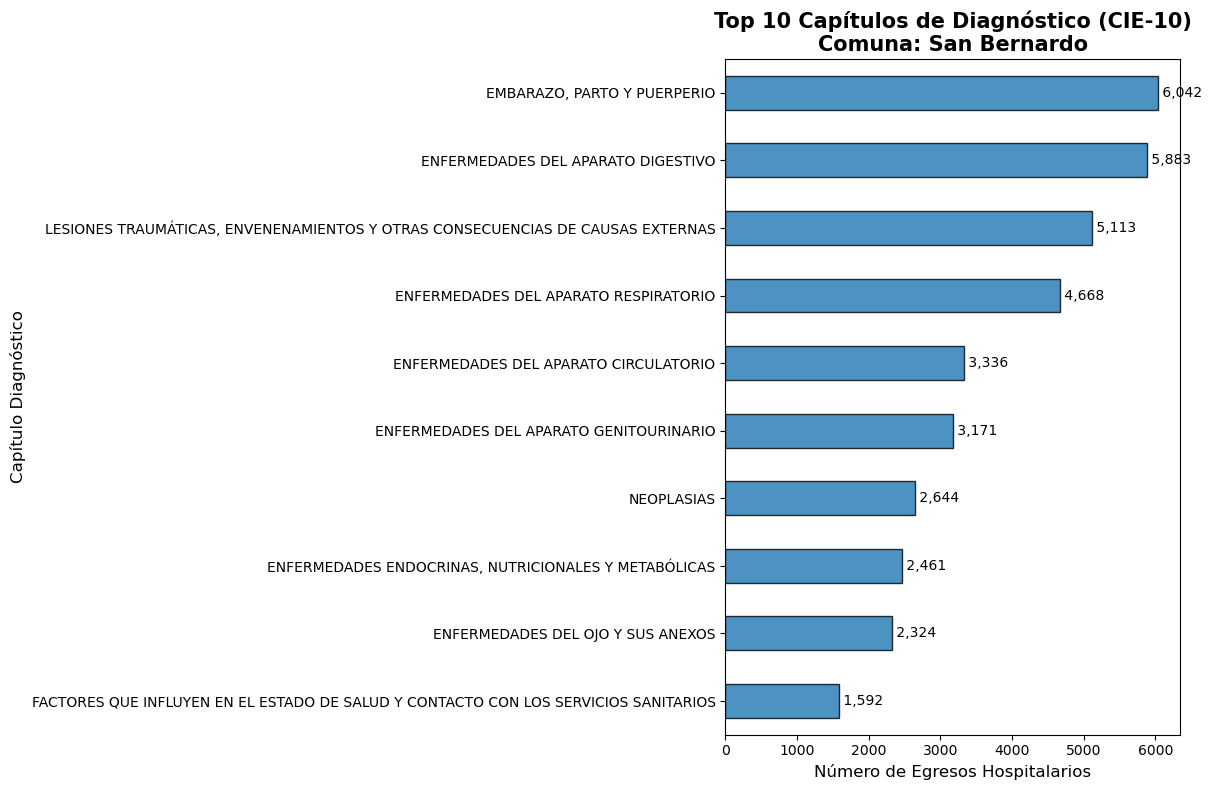

In [42]:
# Se filtra la base de datos para conservar únicamente los registros de San Bernardo
df_sb = grd_com[grd_com["COMUNA"] == "SAN BERNARDO"]

# Se agrupan los egresos por capítulo diagnóstico y se seleccionan los 10 principales
top_10_sb = df_sb["Capítulo"].value_counts().head(10).sort_values(ascending=True)

# Se limpian los nombres de los índices para mejorar la visualización en el gráfico
nombres_limpios_sb = (
    top_10_sb.index.to_series()
    .str.replace(r'^Cap\.\d+\s*', '', regex=True)       # Borra "Cap.XX" y espacios
    .str.replace(r'\s*\([A-Z0-9\-]+\)$', '', regex=True) # Borra "(X00-X99)" y espacios
    .str.strip()
)
top_10_sb.index = nombres_limpios_sb

# Se inicializa la figura con un tamaño adecuado
plt.figure(figsize=(12, 8))

# Se genera el gráfico de barras horizontales
top_10_sb.plot(
    kind='barh', 
    color='tab:blue', 
    edgecolor='black',
    alpha=0.8
)

# Se configuran los títulos y etiquetas de los ejes
plt.title("Top 10 Capítulos de Diagnóstico (CIE-10)\nComuna: San Bernardo", fontsize=15, fontweight='bold')
plt.xlabel("Número de Egresos Hospitalarios", fontsize=12)
plt.ylabel("Capítulo Diagnóstico", fontsize=12)

# Se añaden etiquetas numéricas al final de cada barra para mayor precisión
for index, value in enumerate(top_10_sb):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

# Se ajustan los márgenes para asegurar que los nombres se vean perfectos
plt.tight_layout()
plt.show()

Comentar que el analisis más profundo será siemrpe a la comuna de San Bernardo proudcto de que posee mayor cantidad de datos por su mayor densidad poblacional vs calera de tango

Comenzando que primer lugar se lo lleva una hospitalización la cual no es ninguna enfermedad, sino que los partos, mientras que el segundo lugar son las enfermedades relacionadas al aparato digestivo y el top 3 serían accidentes traumatologícos. Se puede evidenciar que el foco acá son las embarazadas y accidentes traumatologicos, padecimientos que no tienen nada que ver con enfermedades. 

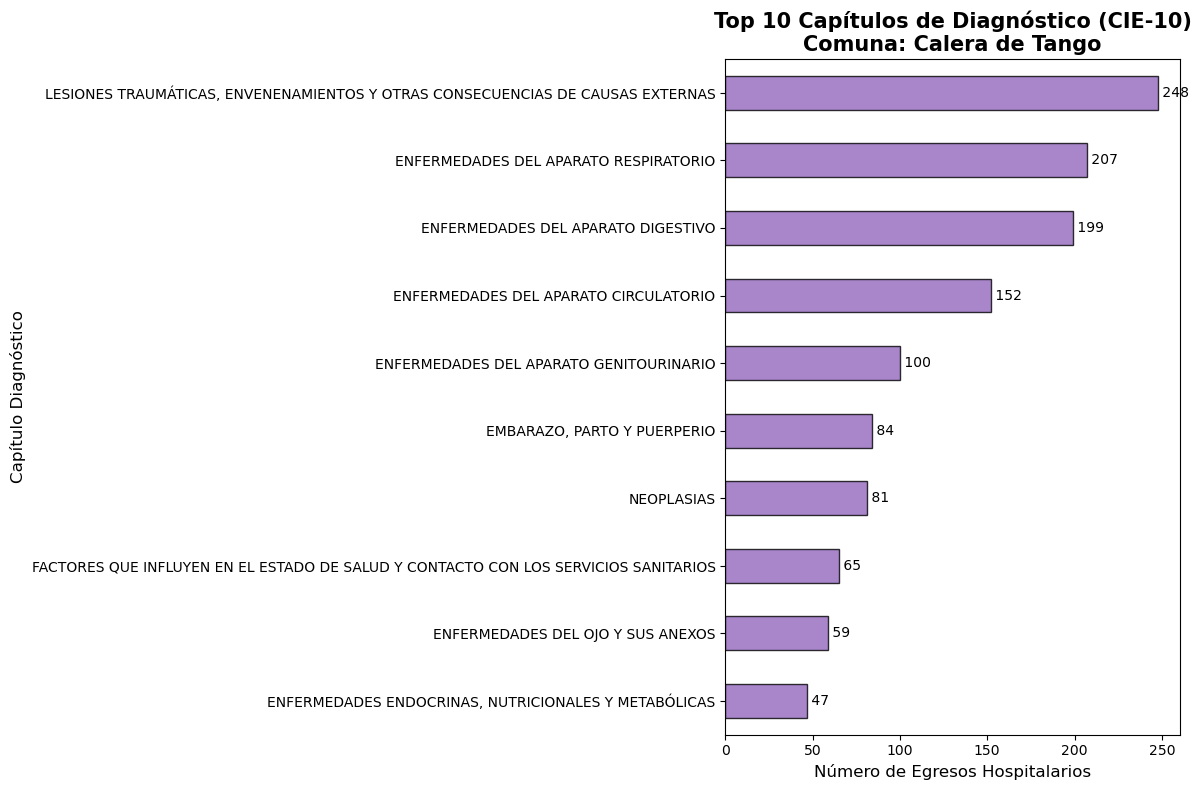

In [41]:
# Se filtra la base de datos para conservar únicamente los registros de Calera de Tango
df_ct = grd_com[grd_com["COMUNA"] == "CALERA DE TANGO"]

# Se agrupan los egresos por capítulo diagnóstico y se seleccionan los 10 principales
top_10_ct = df_ct["Capítulo"].value_counts().head(10).sort_values(ascending=True)

# Se limpian los nombres de los índices para mejorar la visualización en el gráfico
nombres_limpios_ct = (
    top_10_ct.index.to_series()
    .str.replace(r'^Cap\.\d+\s*', '', regex=True)       # Borra "Cap.XX" y espacios
    .str.replace(r'\s*\([A-Z0-9\-]+\)$', '', regex=True) # Borra "(X00-X99)" y espacios
    .str.strip()
)
top_10_ct.index = nombres_limpios_ct

# Se inicializa la figura con un tamaño adecuado
plt.figure(figsize=(12, 8))

# Se genera el gráfico de barras horizontales
top_10_ct.plot(
    kind='barh', 
    color='tab:purple',  # Utilizamos morado para diferenciarlo visualmente de San Bernardo
    edgecolor='black',
    alpha=0.8
)

# Se configuran los títulos y etiquetas de los ejes
plt.title("Top 10 Capítulos de Diagnóstico (CIE-10)\nComuna: Calera de Tango", fontsize=15, fontweight='bold')
plt.xlabel("Número de Egresos Hospitalarios", fontsize=12)
plt.ylabel("Capítulo Diagnóstico", fontsize=12)

# Se añaden etiquetas numéricas al final de cada barra para mayor precisión
for index, value in enumerate(top_10_ct):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

# Se ajustan los márgenes para asegurar que los nombres se vean perfectos
plt.tight_layout()
plt.show()

Acá el lider son los accidentes traumatológicos, seguidos de enfermedades de distintos sistemas del cuerpo, como lo son el respiratorio o el digestivo. 

##### Se recomienda que para ambas comunas que no se enfoquen en las enfermedades, sino en los accidentes y embarazos, ya que son los más habituales. Claramente eso no quiere decir que se dejen de lado los otros pacientes. Sin embargo, se podría estudiar la cantidad de matronas que hay en turno y ver si es que eso da abasto a todas las pacientes.

#### B.1.2 Principales diagnósticos específicos

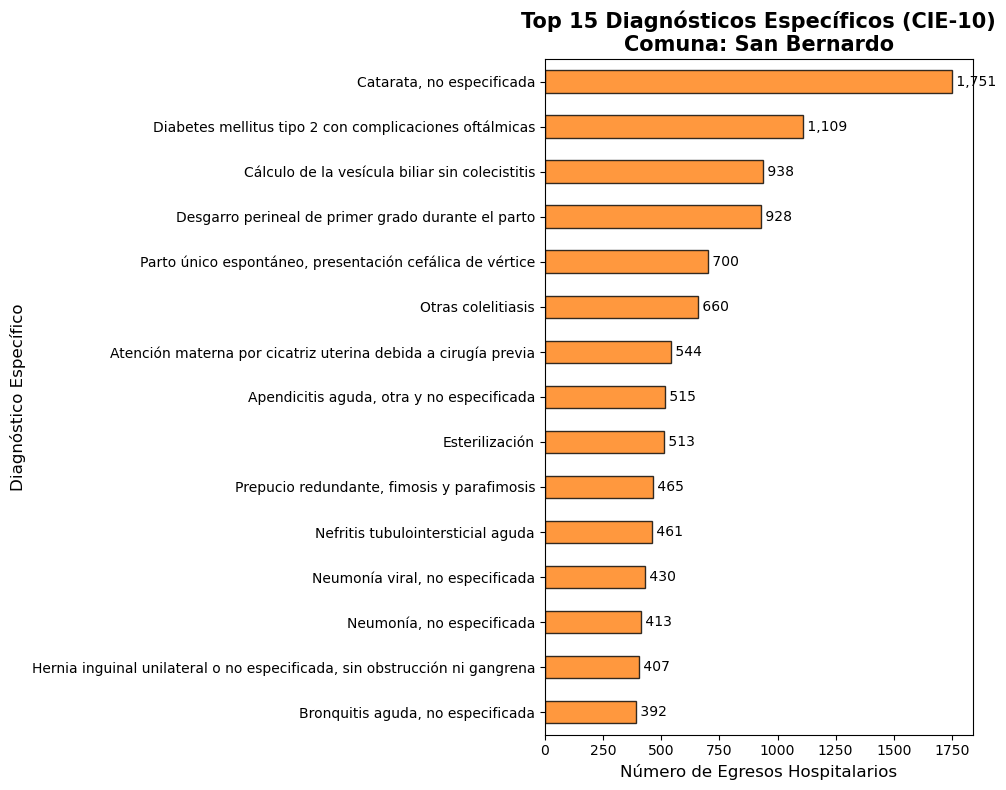

In [38]:
# Se filtra la base de datos para conservar únicamente los registros de San Bernardo
df_sb = grd_com[grd_com["COMUNA"] == "SAN BERNARDO"]

# Se agrupan los egresos por diagnóstico específico (Descripción) y se seleccionan los 15 principales
# Se utiliza sort_values(ascending=True) para que el diagnóstico más frecuente quede en la parte superior
top_15_sb = df_sb["Descripción"].value_counts().head(15).sort_values(ascending=True)

# Se inicializa la figura con un tamaño vertical amplio para evitar que los textos se amontonen
plt.figure(figsize=(10, 8))

# Se genera el gráfico de barras horizontales
top_15_sb.plot(
    kind='barh', 
    color='tab:orange', 
    edgecolor='black',
    alpha=0.8
)

# Se configuran los títulos y etiquetas de los ejes
plt.title("Top 15 Diagnósticos Específicos (CIE-10)\nComuna: San Bernardo", fontsize=15, fontweight='bold')
plt.xlabel("Número de Egresos Hospitalarios", fontsize=12)
plt.ylabel("Diagnóstico Específico", fontsize=12)

# Se añaden etiquetas numéricas al final de cada barra para facilitar la lectura
for index, value in enumerate(top_15_sb):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

# Se ajustan los márgenes
plt.tight_layout()
plt.show()

De las que lideran el top, vemos que están presente varias que estan relacionadas al mundo del embarazo y el parto. Las que pertenecen al top 3, usualemente son consultas que no son de urgencía como si lo es un parto o complicaciónes de este exceptuando el cálculo). Se le recomienda al sistema de salud de dicha comuna que sus camas y personal estén preparadas y disponibles para atender emergencias parto y sus relaciones.

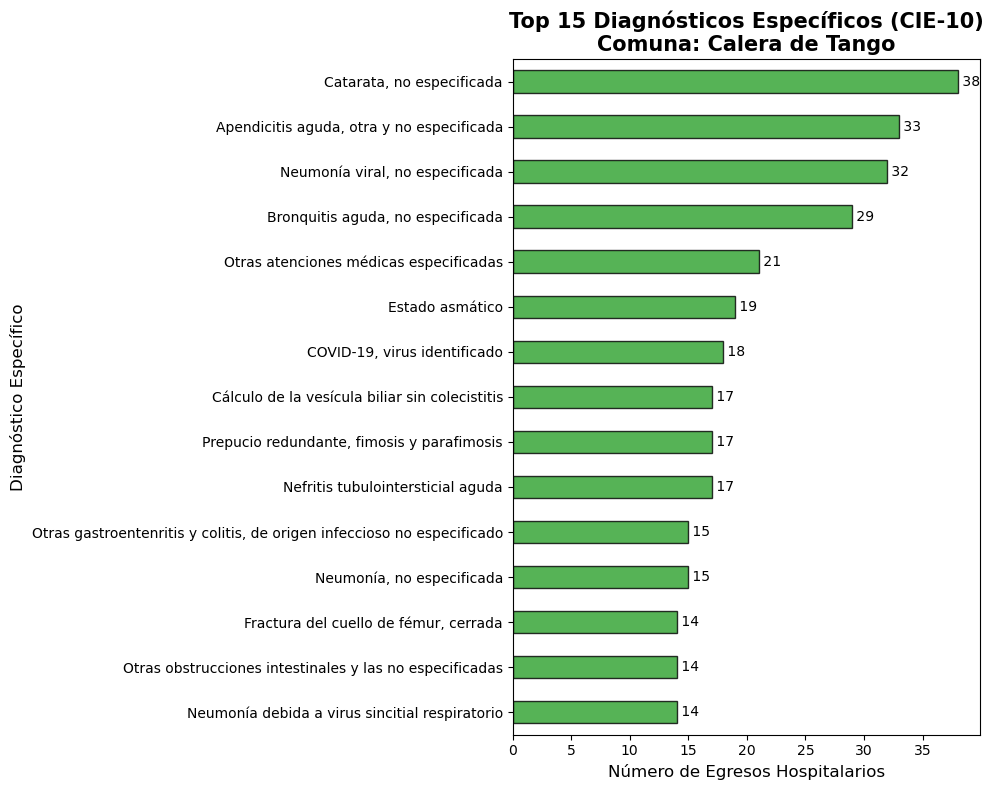

In [39]:
# Se filtra la base de datos para conservar únicamente los registros de Calera de Tango
df_ct = grd_com[grd_com["COMUNA"] == "CALERA DE TANGO"]

# Se agrupan los egresos por diagnóstico específico (Descripción) y se seleccionan los 15 principales
top_15_ct = df_ct["Descripción"].value_counts().head(15).sort_values(ascending=True)

# Se inicializa la figura con un tamaño vertical amplio
plt.figure(figsize=(10, 8))

# Se genera el gráfico de barras horizontales
top_15_ct.plot(
    kind='barh', 
    color='tab:green',  # Se utiliza otro color para diferenciarlo visualmente de San Bernardo
    edgecolor='black',
    alpha=0.8
)

# Se configuran los títulos y etiquetas de los ejes
plt.title("Top 15 Diagnósticos Específicos (CIE-10)\nComuna: Calera de Tango", fontsize=15, fontweight='bold')
plt.xlabel("Número de Egresos Hospitalarios", fontsize=12)
plt.ylabel("Diagnóstico Específico", fontsize=12)

# Se añaden etiquetas numéricas al final de cada barra
for index, value in enumerate(top_15_ct):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10)

# Se ajustan los márgenes
plt.tight_layout()
plt.show()

acá pasa lo contrario, la mayoría de las enfermedades son cosas ya bastante graves, por lo que se le sugiere que el personal esté preparado para cualquier eventualidad. Recomendar usar mascarilla, ya que, muchas de estas están relacionadas al sistema respiratorio. 

#### B.1.3 Capítulos de diagnóstico por nacionalidad

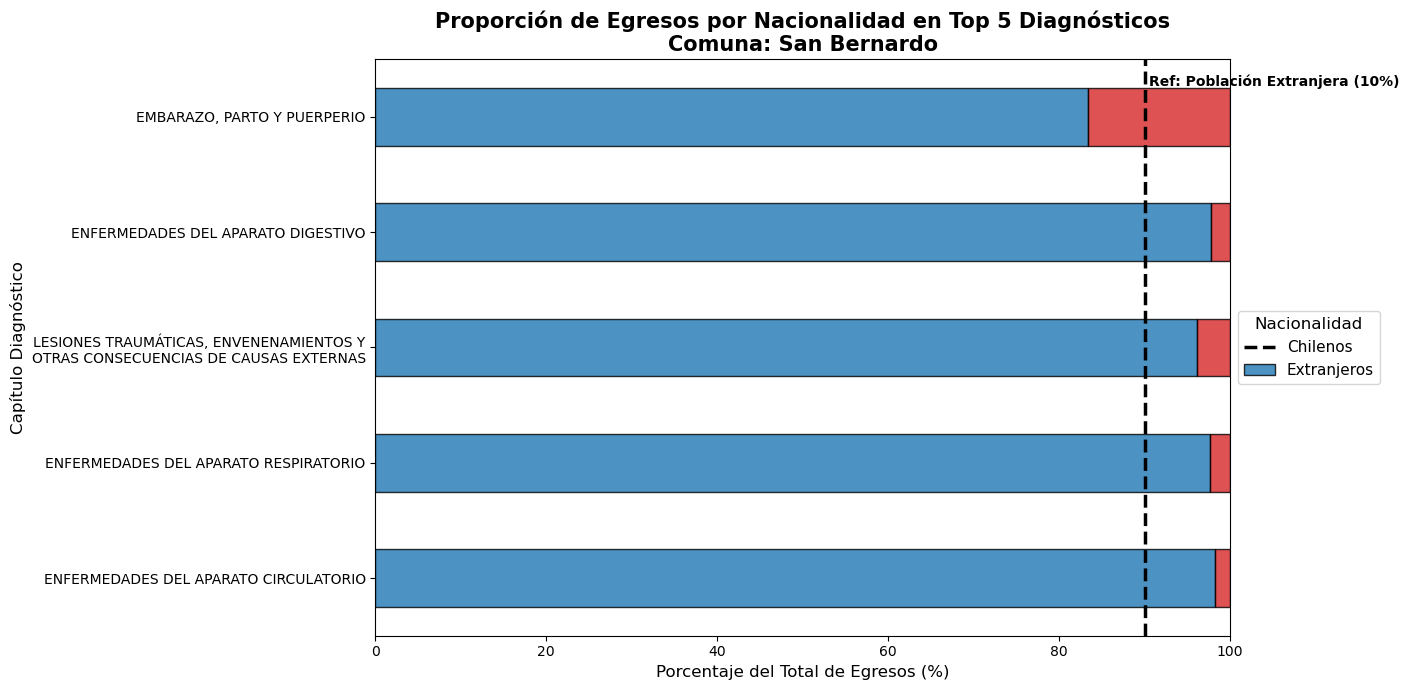

=== Proporción exacta por Capítulo (San Bernardo) ===


nat_group,Chilean,Foreign
cap_limpio,,
ENFERMEDADES DEL APARATO CIRCULATORIO,98.2,1.8
ENFERMEDADES DEL APARATO RESPIRATORIO,97.7,2.3
"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y\nOTRAS CONSECUENCIAS DE CAUSAS EXTERNAS",96.1,3.9
ENFERMEDADES DEL APARATO DIGESTIVO,97.8,2.2
"EMBARAZO, PARTO Y PUERPERIO",83.4,16.6


In [48]:
# Se filtra la base de datos para San Bernardo
df_sb = grd_com[grd_com["COMUNA"] == "SAN BERNARDO"]

# Se identifican los 5 capítulos principales
top_5_sb = df_sb["Capítulo"].value_counts().head(5).index
df_top5_sb = df_sb[df_sb["Capítulo"].isin(top_5_sb)].copy()

# Se limpian los nombres de los capítulos y se ajustan a un máximo de 40 caracteres por línea
nombres_limpios_sb = (
    df_top5_sb["Capítulo"]
    .str.replace(r'^Cap\.\d+\s*', '', regex=True)
    .str.replace(r'\s*\([A-Z0-9\-]+\)$', '', regex=True)
    .str.strip()
    .apply(lambda x: textwrap.fill(x, width=40)) # <- Esto "dobla" los textos largos
)
df_top5_sb["cap_limpio"] = nombres_limpios_sb

# Se calcula la proporción por fila y se ordena (mayor volumen arriba)
prop_sb = pd.crosstab(df_top5_sb["cap_limpio"], df_top5_sb["nat_group"], normalize='index') * 100
orden_sb = df_top5_sb["cap_limpio"].value_counts().index
prop_sb = prop_sb.loc[orden_sb[::-1]] 

# Se inicializa la figura espaciosa
fig, ax = plt.subplots(figsize=(14, 7))

# Se genera el gráfico de barras apiladas al 100%
prop_sb.plot(
    kind='barh', 
    stacked=True, 
    ax=ax,
    color=['tab:blue', 'tab:red'], 
    edgecolor='black',
    alpha=0.8
)

# Se configuran los títulos y etiquetas
plt.title("Proporción de Egresos por Nacionalidad en Top 5 Diagnósticos\nComuna: San Bernardo", fontsize=15, fontweight='bold')
plt.xlabel("Porcentaje del Total de Egresos (%)", fontsize=12)
plt.ylabel("Capítulo Diagnóstico", fontsize=12)

# Se establece el eje X estrictamente del 0 al 100%
ax.set_xlim(0, 100)

# --- Referencia Visual ---
# *NOTA: Cambia '10' por el pct_foreign real de San Bernardo en tu Tarea 1
line_val_sb = 90.0 
plt.axvline(x=line_val_sb, color='black', linestyle='--', linewidth=2.5)

# Etiqueta flotante
plt.text(line_val_sb + 0.5, 4.3, 'Ref: Población Extranjera (10%)', color='black', fontweight='bold', fontsize=10, va='center')

# Se configura la leyenda limpia fuera del gráfico
plt.legend(labels=['Chilenos', 'Extranjeros'], title="Nacionalidad", fontsize=11, title_fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))

# Se ajustan los márgenes para asegurar que todo quepa perfectamente
plt.tight_layout()
plt.show()

# Se muestra la tabla exacta para el reporte
print("=== Proporción exacta por Capítulo (San Bernardo) ===")
display(prop_sb.round(1))

Con la comuna de San Bernardo, vemos que las enfermedades que no están relacionadas a embarazo lideran los chilenos con las consultas, mientras que en embarazo, si bien las extranjeras no ganan a las chilenas, si poseen más porcentaje que en las otras.

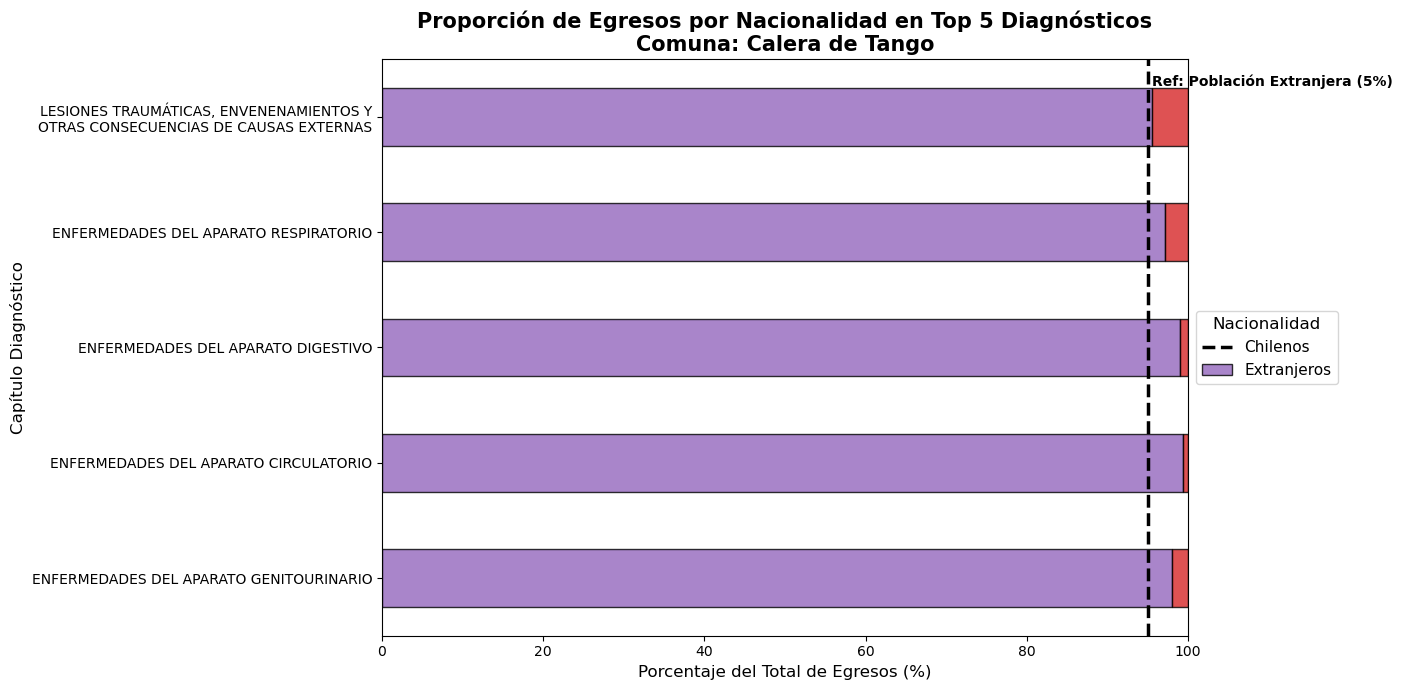

=== Proporción exacta por Capítulo (Calera de Tango) ===


nat_group,Chilean,Foreign
cap_limpio,,
ENFERMEDADES DEL APARATO GENITOURINARIO,98.0,2.0
ENFERMEDADES DEL APARATO CIRCULATORIO,99.3,0.7
ENFERMEDADES DEL APARATO DIGESTIVO,99.0,1.0
ENFERMEDADES DEL APARATO RESPIRATORIO,97.1,2.9
"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y\nOTRAS CONSECUENCIAS DE CAUSAS EXTERNAS",95.6,4.4


In [49]:
# Se filtra la base de datos para conservar únicamente los registros de Calera de Tango
df_ct = grd_com[grd_com["COMUNA"] == "CALERA DE TANGO"]

# Se identifican los 5 capítulos principales
top_5_ct = df_ct["Capítulo"].value_counts().head(5).index
df_top5_ct = df_ct[df_ct["Capítulo"].isin(top_5_ct)].copy()

# Se limpian los nombres de los capítulos y se ajustan a un máximo de 40 caracteres por línea
nombres_limpios_ct = (
    df_top5_ct["Capítulo"]
    .str.replace(r'^Cap\.\d+\s*', '', regex=True)
    .str.replace(r'\s*\([A-Z0-9\-]+\)$', '', regex=True)
    .str.strip()
    .apply(lambda x: textwrap.fill(x, width=40)) # <- Esto "dobla" los textos largos
)
df_top5_ct["cap_limpio"] = nombres_limpios_ct

# Se calcula la proporción por fila y se ordena (mayor volumen arriba)
prop_ct = pd.crosstab(df_top5_ct["cap_limpio"], df_top5_ct["nat_group"], normalize='index') * 100
orden_ct = df_top5_ct["cap_limpio"].value_counts().index
prop_ct = prop_ct.loc[orden_ct[::-1]]

# Se inicializa la figura espaciosa
fig, ax = plt.subplots(figsize=(14, 7))

# Se genera el gráfico de barras apiladas al 100%
prop_ct.plot(
    kind='barh', 
    stacked=True, 
    ax=ax,
    color=['tab:purple', 'tab:red'], # Morado para chilenos, rojo para extranjeros en Calera de Tango
    edgecolor='black',
    alpha=0.8
)

# Se configuran títulos y etiquetas
plt.title("Proporción de Egresos por Nacionalidad en Top 5 Diagnósticos\nComuna: Calera de Tango", fontsize=15, fontweight='bold')
plt.xlabel("Porcentaje del Total de Egresos (%)", fontsize=12)
plt.ylabel("Capítulo Diagnóstico", fontsize=12)

# Se establece el eje X estrictamente del 0 al 100%
ax.set_xlim(0, 100)

# --- Referencia Visual ---
# *NOTA: Cambia '5' por el porcentaje de población extranjera real de Calera de Tango en tu Tarea 1
line_val_ct = 95.0 # Si la población extranjera es 5%, la línea va en el 95%
plt.axvline(x=line_val_ct, color='black', linestyle='--', linewidth=2.5)

# Etiqueta flotante
plt.text(line_val_ct + 0.5, 4.3, 'Ref: Población Extranjera (5%)', color='black', fontweight='bold', fontsize=10, va='center')

# Se configura la leyenda limpia fuera del gráfico
plt.legend(labels=['Chilenos', 'Extranjeros'], title="Nacionalidad", fontsize=11, title_fontsize=12, loc='center left', bbox_to_anchor=(1, 0.5))

# Se ajustan los márgenes para asegurar que todo quepa perfectamente
plt.tight_layout()
plt.show()

# Se muestra la tabla exacta para el reporte
print("=== Proporción exacta por Capítulo (Calera de Tango) ===")
display(prop_ct.round(1))

Acá casi que ni aparecen los extranjeros

##### Sugiero que el sistema de salud de dichas comunas no completan los datos de la nacionalidad cuadno las personas son extrangeras y que posiblemente los porcentajes sean mayores que los vistos, independiente de que la proporción chilenos vs extranjero siempre ganan los nacidos en Chile, 

## B.2 Duración de la Estadía y Severidad
##### B.2.1 Duración de la estadía por nacionalidad

=== Duración de la Estadía por Nacionalidad ===


Media (días)  Mediana (días)
COMUNA          nat_group                              
CALERA DE TANGO Chilean            7.24             3.0
                Foreign            6.43             3.0
SAN BERNARDO    Chilean            6.04             2.0
                Foreign            5.52             3.0

C:\Users\Mateo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


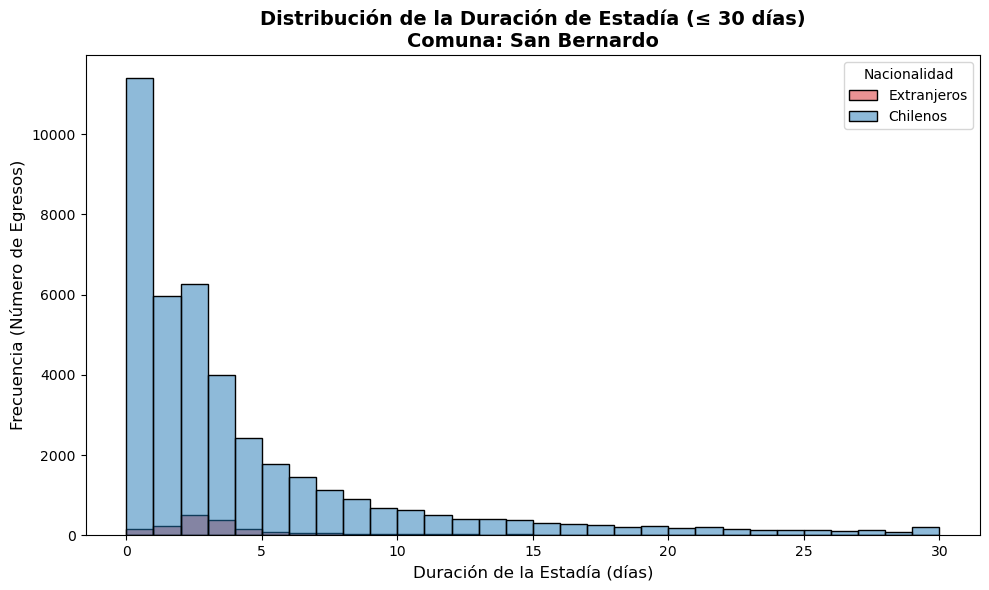

C:\Users\Mateo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


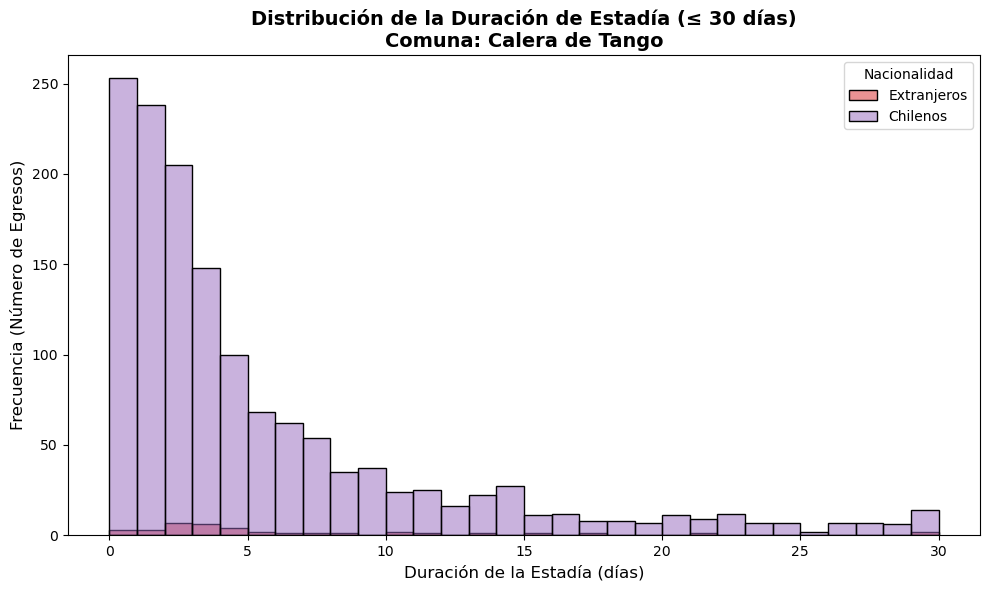

In [63]:
# Se agrupan los datos por Comuna y Nacionalidad para calcular la media y la mediana
tabla_los = grd_com.groupby(["COMUNA", "nat_group"])["los"].agg(["mean", "median"]).round(2)

# Se renombran las columnas para una presentación más profesional
tabla_los.columns = ["Media (días)", "Mediana (días)"]

# Se imprime la tabla resumen
print("=== Duración de la Estadía por Nacionalidad ===")
display(tabla_los)

# Se filtra la base general limitando a estadías de hasta 30 días para los gráficos
df_30 = grd_com[grd_com["los"] <= 30]

# Gráfico para San Bernardo

df_sb_30 = df_30[df_30["COMUNA"] == "SAN BERNARDO"]

# Se inicializa la figura para el primer histograma
plt.figure(figsize=(10, 6))

# Se genera el histograma superpuesto
sns.histplot(
    data=df_sb_30, 
    x="los", 
    hue="nat_group", 
    bins=30, 
    palette={"Chilean": "tab:blue", "Foreign": "tab:red"},
    alpha=0.5, 
    kde=False
)

# Se configuran los títulos y etiquetas
plt.title("Distribución de la Duración de Estadía (≤ 30 días)\nComuna: San Bernardo", fontsize=14, fontweight='bold')
plt.xlabel("Duración de la Estadía (días)", fontsize=12)
plt.ylabel("Frecuencia (Número de Egresos)", fontsize=12)
plt.legend(title="Nacionalidad", labels=['Extranjeros', 'Chilenos'])

# Se ajustan los márgenes y se muestra el primer gráfico
plt.tight_layout()
plt.show()

# Gráfico para Calera de Tango

df_ct_30 = df_30[df_30["COMUNA"] == "CALERA DE TANGO"]

# Se inicializa la figura para el segundo histograma
plt.figure(figsize=(10, 6))

# Se genera el histograma superpuesto
sns.histplot(
    data=df_ct_30, 
    x="los", 
    hue="nat_group", 
    bins=30, 
    palette={"Chilean": "tab:purple", "Foreign": "tab:red"},
    alpha=0.5, 
    kde=False
)

# Se configuran los títulos y etiquetas
plt.title("Distribución de la Duración de Estadía (≤ 30 días)\nComuna: Calera de Tango", fontsize=14, fontweight='bold')
plt.xlabel("Duración de la Estadía (días)", fontsize=12)
plt.ylabel("Frecuencia (Número de Egresos)", fontsize=12)
plt.legend(title="Nacionalidad", labels=['Extranjeros', 'Chilenos'])

# Se ajustan los márgenes y se muestra el segundo gráfico
plt.tight_layout()
plt.show()

En ambas comunas se logra ver la misma distribución de días, la cual es una exponencial decreciente

#### B.2.2 Cargar Etiquetas de Severidad y Graficar

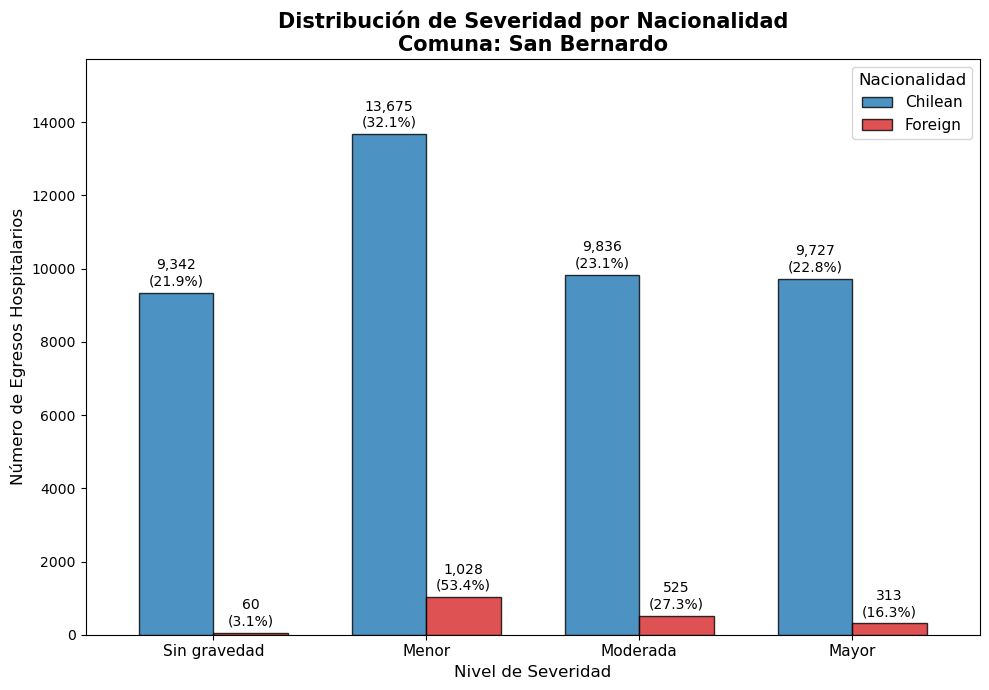

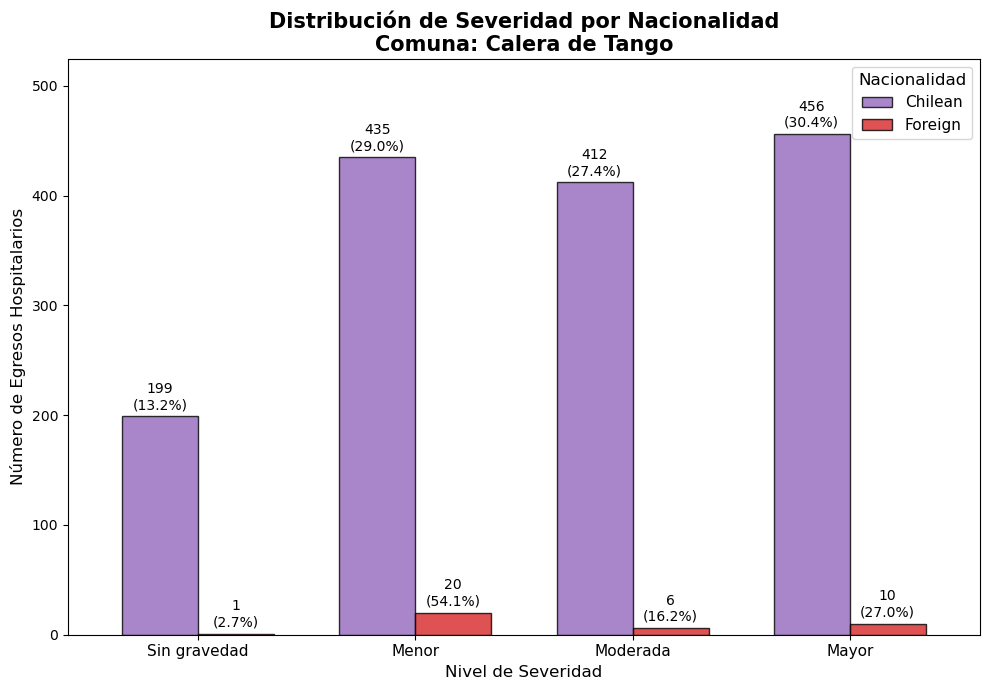

In [65]:
# Se define la ruta y se carga la hoja de Severidad desde el archivo maestro
ruta_tablas = "C:/Users/Mateo/Downloads/iele26_data/grd/TablasMaestrasBasesGRD.xlsx"
sev_labels = pd.read_excel(ruta_tablas, sheet_name="Severidad GRD")

# Se renombran las columnas para asegurar la compatibilidad
sev_labels.columns = ["codigo_sev", "etiqueta_severidad"]

# Se igualan los tipos de datos a formato numérico para evitar errores de cruce
grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors="coerce")
sev_labels["codigo_sev"] = pd.to_numeric(sev_labels["codigo_sev"], errors="coerce")

# Se cruza la base original con las etiquetas en caso de no haberse realizado previamente
if "etiqueta_severidad" not in grd_com.columns:
    grd_com = grd_com.merge(sev_labels, left_on="IR_29301_SEVERIDAD", right_on="codigo_sev", how="left")

# Se extrae el orden original de gravedad clínica desde el archivo Excel
orden_sev = sev_labels.sort_values("codigo_sev")["etiqueta_severidad"].tolist()

# Se filtra la base de datos para San Bernardo y se prepara su tabla de contingencia
df_sb = grd_com[grd_com["COMUNA"] == "SAN BERNARDO"]
conteo_sb = pd.crosstab(df_sb["etiqueta_severidad"], df_sb["nat_group"])
conteo_sb = conteo_sb.reindex([x for x in orden_sev if x in conteo_sb.index])

# Se inicializa la primera figura con altura suficiente para acomodar los textos
fig1, ax1 = plt.subplots(figsize=(10, 7))

# Se genera el gráfico de barras
conteo_sb.plot(
    kind='bar', 
    ax=ax1,
    color=['tab:blue', 'tab:red'], 
    edgecolor='black',
    alpha=0.8,
    width=0.7
)

# Se configuran los títulos y etiquetas
plt.title("Distribución de Severidad por Nacionalidad\nComuna: San Bernardo", fontsize=15, fontweight='bold')
plt.xlabel("Nivel de Severidad", fontsize=12)
plt.ylabel("Número de Egresos Hospitalarios", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Nacionalidad", fontsize=11, title_fontsize=12)

# Se añaden etiquetas con cantidad y porcentaje (sin forzar la alineación)
for i, container in enumerate(ax1.containers):
    total_grupo_sb = conteo_sb.iloc[:, i].sum()
    etiquetas_sb = [f"{val:,.0f}\n({(val/total_grupo_sb)*100:.1f}%)" if val > 0 else "" for val in container.datavalues]
    ax1.bar_label(container, labels=etiquetas_sb, padding=3, fontsize=10)

# Se aumenta el límite superior del gráfico
ax1.set_ylim(0, conteo_sb.max().max() * 1.15)

# Se ajustan márgenes y se muestra el primer gráfico
plt.tight_layout()
plt.show()

# Se filtra la base de datos para Calera de Tango y se prepara su tabla de contingencia
df_ct = grd_com[grd_com["COMUNA"] == "CALERA DE TANGO"]
conteo_ct = pd.crosstab(df_ct["etiqueta_severidad"], df_ct["nat_group"])
conteo_ct = conteo_ct.reindex([x for x in orden_sev if x in conteo_ct.index])

# Se inicializa la segunda figura independiente
fig2, ax2 = plt.subplots(figsize=(10, 7))

# Se genera el gráfico de barras
conteo_ct.plot(
    kind='bar', 
    ax=ax2,
    color=['tab:purple', 'tab:red'], 
    edgecolor='black',
    alpha=0.8,
    width=0.7
)

# Se configuran los títulos y etiquetas
plt.title("Distribución de Severidad por Nacionalidad\nComuna: Calera de Tango", fontsize=15, fontweight='bold')
plt.xlabel("Nivel de Severidad", fontsize=12)
plt.ylabel("Número de Egresos Hospitalarios", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Nacionalidad", fontsize=11, title_fontsize=12)

# Se añaden etiquetas con cantidad y porcentaje (sin forzar la alineación)
for i, container in enumerate(ax2.containers):
    total_grupo_ct = conteo_ct.iloc[:, i].sum()
    etiquetas_ct = [f"{val:,.0f}\n({(val/total_grupo_ct)*100:.1f}%)" if val > 0 else "" for val in container.datavalues]
    ax2.bar_label(container, labels=etiquetas_ct, padding=3, fontsize=10)

# Se aumenta el límite superior del gráfico
ax2.set_ylim(0, conteo_ct.max().max() * 1.15)

# Se ajustan márgenes y se muestra el segundo gráfico
plt.tight_layout()
plt.show()

Al analizar los gráficos de distribución de la estadía, se observa que en ambas comunas la gran mayoría de los pacientes (tanto chilenos como extranjeros) concentra sus altas en los primeros días, lo que explica que las medianas sean tan parecidas. Sin embargo, al mirar la extensión del gráfico hacia la derecha (la "cola"), se nota claramente que los pacientes chilenos presentan muchas más hospitalizaciones prolongadas que superan los 10 o 20 días. Esto indica que, si bien la mayoría entra y sale rápido, la población chilena es la que ocupa las camas del hospital por periodos más largos, probablemente debido a tratamientos más complejos o recuperación de enfermedades crónicas.

#### B.2.3 Tipo de alta y Tasa de mortalidad

In [55]:
# Se calcula la distribución de los resultados de alta por comuna
distribucion_alta = grd_com.groupby("COMUNA")["TIPOALTA"].value_counts().unstack(fill_value=0)

# Se reporta la tabla con la distribución de los tipos de alta
print("=== Distribución de Resultados de Alta por Comuna ===")
display(distribucion_alta)

# Se crea una columna indicadora (booleana) para identificar exclusivamente los fallecimientos
grd_com["fallecido"] = grd_com["TIPOALTA"] == "FALLECIDO"

# Se calcula la tasa de mortalidad intrahospitalaria agrupando por comuna y nacionalidad
# Promediar una variable booleana entrega exactamente la proporción, la cual se multiplica por 100 para obtener el porcentaje
tasa_mortalidad = (grd_com.groupby(["COMUNA", "nat_group"])["fallecido"].mean() * 100).round(2)

# Se formatea la tabla para una presentación limpia y profesional
tabla_mortalidad = tasa_mortalidad.unstack(level="nat_group").astype(str) + "%"
tabla_mortalidad.columns.name = "Nacionalidad"
tabla_mortalidad.index.name = "Comuna"

# Se imprime la tabla resumen solicitada
print("\n=== Tasa de Mortalidad Intrahospitalaria por Nacionalidad ===")
display(tabla_mortalidad)

=== Distribución de Resultados de Alta por Comuna ===


TIPOALTA,ALTA VOLUNTARIA,"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,DERIVACIÓN INST. PRIVADA (VOLUNTARIO),DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,DOMICILIO,FALLECIDO,FUGA DEL PACIENTE,HOSPITALIZACIÓN DOMICILIARIA
COMUNA,,,,,,,,,,
CALERA DE TANGO,19,2,5,2,7,22,1413,40,1,28
SAN BERNARDO,834,115,1000,38,505,1195,37249,1044,387,2139



=== Tasa de Mortalidad Intrahospitalaria por Nacionalidad ===


Nacionalidad,Chilean,Foreign
Comuna,,
CALERA DE TANGO,2.66%,0.0%
SAN BERNARDO,2.4%,1.14%


La tabla muestra que la tasa de mortalidad intrahospitalaria es mayor en pacientes chilenos que en extranjeros. Esto no refleja una diferencia en la calidad de atención, sino un sesgo demográfico: los pacientes extranjeros son mayoritariamente jóvenes y se hospitalizan por causas de muy bajo riesgo vital (principalmente embarazo y parto). En contraste, los pacientes chilenos representan a una población más envejecida y concentran las hospitalizaciones por enfermedades crónicas, severas o degenerativas, lo que eleva naturalmente su tasa de mortalidad.

#### B.3.1 Coroplético: tasa de hospitalización por comuna

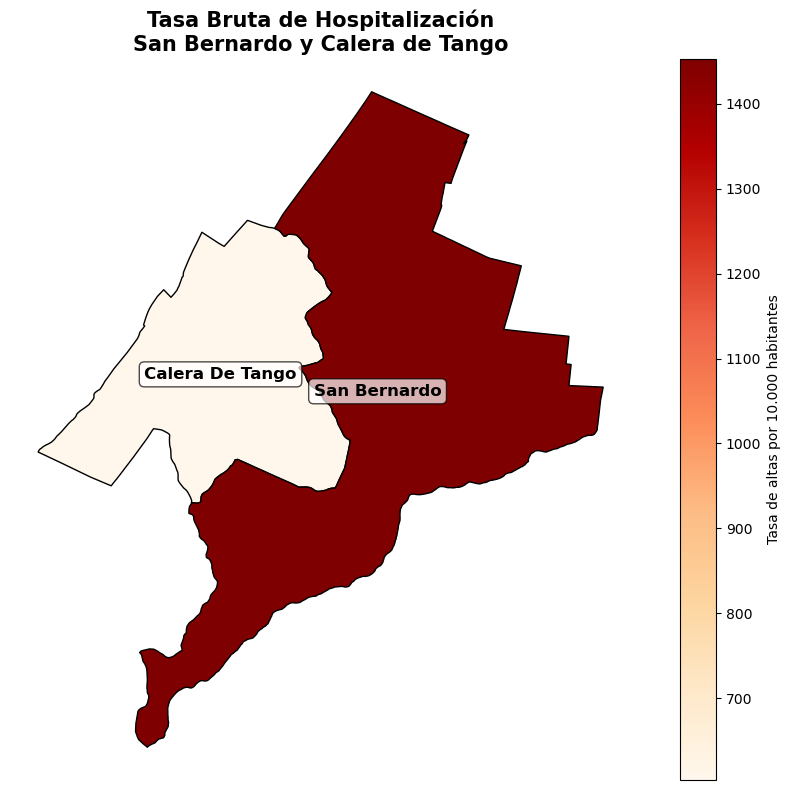

In [57]:
# Se carga la base de datos de población obtenida en la Tarea 1
ruta_poblacion = "C:/Users/Mateo/Downloads/tarea1_comuna_summary.csv"
df_pob = pd.read_csv(ruta_poblacion)

# Se estandarizan los nombres de las comunas a mayúsculas para asegurar el cruce perfecto de los datos
df_pob["nombre_comuna"] = df_pob["nombre_comuna"].str.upper()

# Se calcula el total de altas hospitalarias por comuna desde la base GRD
altas_comuna = grd_com["COMUNA"].value_counts().reset_index()
altas_comuna.columns = ["COMUNA", "total_altas"]

# Se unen las altas hospitalarias con los datos de población
tasas_df = altas_comuna.merge(df_pob, left_on="COMUNA", right_on="nombre_comuna", how="left")

# Se calcula la tasa bruta de hospitalización por cada 10.000 habitantes
tasas_df["tasa_hosp_10k"] = (tasas_df["total_altas"] / tasas_df["pop_total"]) * 10000

# Se define la ruta del shapefile (adaptada a la estructura de carpetas local)
ruta_shp = "C:/Users/Mateo/Downloads/comunas.shp"

# Se carga el archivo espacial utilizando Geopandas
comunas_gdf = gpd.read_file(ruta_shp)

# Se estandarizan los nombres de las comunas en el shapefile a mayúsculas
# (Se asume que la columna de nombres en el shapefile se llama 'Comuna')
comunas_gdf["comuna_match"] = comunas_gdf["Comuna"].str.upper()

# Se une el geodataframe con la tabla de tasas de hospitalización calculadas
mapa_gdf = comunas_gdf.merge(tasas_df, left_on="comuna_match", right_on="COMUNA", how="inner")

# Se inicializa la figura para el mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Se genera el mapa coroplético utilizando la tasa calculada
mapa_gdf.plot(
    column="tasa_hosp_10k", 
    cmap="OrRd",           # Se utiliza una escala térmica (Naranjas y Rojos)
    linewidth=1, 
    ax=ax, 
    edgecolor="black", 
    legend=True,
    legend_kwds={'label': "Tasa de altas por 10.000 habitantes", 'orientation': "vertical"}
)

# Se configuran los títulos y se eliminan los ejes de coordenadas por estética
ax.set_title("Tasa Bruta de Hospitalización\nSan Bernardo y Calera de Tango", fontsize=15, fontweight="bold")
ax.axis("off")

# Se añaden las etiquetas de texto con el nombre de cada comuna en el centro de su respectivo polígono espacial
for idx, row in mapa_gdf.iterrows():
    ax.annotate(
        text=row["COMUNA"].title(),
        xy=(row["geometry"].centroid.x, row["geometry"].centroid.y),
        xytext=(0, 0),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        color="black",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.7) # Fondo blanco semitransparente para que el texto se lea perfecto
    )

# Se ajustan los márgenes de la visualización
plt.tight_layout()
plt.show()

Acá la grafica se ve así pero porque la cantidad de poblacion de ambas comunas son muy dispares. Lo interesante sería ver como son los porcentajes de ambas comunas y ahí recien sacar conclusiones.

#### B.4 Tabla Resumen de GRD a Nivel de Comuna

In [58]:
# Se carga nuevamente la base de población de la Tarea 1 para asegurar tener la columna pop_total
ruta_poblacion = "C:/Users/Mateo/Downloads/tarea1_comuna_summary.csv"
df_pob = pd.read_csv(ruta_poblacion)

# Se asegura que el nombre de la comuna esté en mayúsculas para el cruce
df_pob["nombre_comuna_upper"] = df_pob["nombre_comuna"].str.upper()

# Se define la función que agrupa y calcula las métricas solicitadas para cada comuna
def build_grd_summary(df):
    total = len(df)
    chilean = (df["nat_group"] == "Chilean").sum()
    foreign = (df["nat_group"] == "Foreign").sum()
    
    pct_foreign = (foreign / total) * 100 if total > 0 else 0
    
    mean_los = df["los"].mean()
    mean_los_chi = df[df["nat_group"] == "Chilean"]["los"].mean()
    mean_los_for = df[df["nat_group"] == "Foreign"]["los"].mean()
    
    mean_sev = df["IR_29301_SEVERIDAD"].mean()
    
    # Se asume que la columna 'fallecido' fue creada en el paso B.2.3
    mort_rate = (df["fallecido"].sum() / total) * 100 if total > 0 else 0

    # Se extraen los 3 capítulos principales y se limpian sus textos
    top3 = df["Capítulo"].value_counts().head(3).index.tolist()
    top3_clean = [re.sub(r'^Cap\.\d+\s*', '', str(c)) for c in top3]
    top3_clean = [re.sub(r'\s*\([A-Z0-9\-]+\)$', '', str(c)).strip() for c in top3_clean]
    top3_str = ", ".join(top3_clean)

    return pd.Series({
        "grd_total": total,
        "grd_chilean": chilean,
        "grd_foreign": foreign,
        "grd_pct_foreign": round(pct_foreign, 2),
        "grd_mean_los": round(mean_los, 2),
        "grd_mean_los_chilean": round(mean_los_chi, 2),
        "grd_mean_los_foreign": round(mean_los_for, 2),
        "grd_mean_severity": round(mean_sev, 2),
        "grd_mortality_rate": round(mort_rate, 2),
        "grd_top3_chapters": top3_str
    })

# Se aplica la función sobre la base de datos agrupada por comuna
grd_summary = grd_com.groupby("COMUNA").apply(build_grd_summary).reset_index()

# Se mapean los códigos y nombres legibles de las comunas
mapa_codigos = {"SAN BERNARDO": 13401, "CALERA DE TANGO": 13403}
mapa_nombres = {"SAN BERNARDO": "San Bernardo", "CALERA DE TANGO": "Calera de Tango"}

grd_summary["codigo_comuna"] = grd_summary["COMUNA"].map(mapa_codigos)
grd_summary["nombre_comuna"] = grd_summary["COMUNA"].map(mapa_nombres)

# Se une el resumen con los datos poblacionales para obtener 'pop_total'
grd_summary = grd_summary.merge(
    df_pob[["nombre_comuna_upper", "pop_total"]], 
    left_on="COMUNA", 
    right_on="nombre_comuna_upper", 
    how="left"
)

# Se calcula la tasa bruta de hospitalización
grd_summary["grd_rate_per_10k"] = round((grd_summary["grd_total"] / grd_summary["pop_total"]) * 10000, 2)

# Se ordenan las columnas exactamente como lo solicita la pauta
columnas_ordenadas = [
    "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean",
    "grd_foreign", "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
    "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
    "grd_top3_chapters", "grd_rate_per_10k"
]
grd_summary = grd_summary[columnas_ordenadas]

# Se muestra la tabla final en el notebook
print("=== Tabla Resumen de GRD a Nivel de Comuna ===")
display(grd_summary)

# Se guarda el archivo CSV exclusivamente en la carpeta de Descargas
ruta_salida = "C:/Users/Mateo/Downloads/tarea2_grd_summary.csv"
grd_summary.to_csv(ruta_salida, index=False, encoding="utf-8")

print(f"\nEl archivo CSV se ha guardado exitosamente en: {ruta_salida}")

=== Tabla Resumen de GRD a Nivel de Comuna ===


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13403,Calera de Tango,1539,1502,37,2.40,7.22,7.24,6.43,1.75,2.60,"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS ...",603.74
1,13401,San Bernardo,44506,42580,1926,4.33,6.01,6.04,5.52,1.47,2.35,"EMBARAZO, PARTO Y PUERPERIO, ENFERMEDADES DEL ...",1452.68



El archivo CSV se ha guardado exitosamente en: C:/Users/Mateo/Downloads/tarea2_grd_summary.csv
